#
# <center> Credit Card Fraud Dataset Data Mining - Spring 2026
## <center> Created By: Saba Berenji

# Descriptive Summary

This dataset is obtained from a Kaggle repository called Credit Card Fraud (https://www.kaggle.com/datasets/dhanushnarayananr/credit-card-fraud), while the source of the dataset is unknown. It provides information on credit card transactions (for when card was present during purchase and also not present). This dataset has 1M records and 8 attributes such as distance_from_home, distance_from_last_transaction, repeat_retailer, online_order, fraud, etc. The dataset was loaded into MongoDB and broken down into three tables. The analysis showed that continuous variables in this dataset (distance_from_home, distance_from_last_transaction, and ratio_to_median_purchase_price) were positively skewed. Three outlier detection techniques were used (IQR, KNN, and Location Outlier Factor) and KNN provided the highest fraud detection rate among the identified outliers. Finally, association rule mining was used to indentify, positive, rare and negative rules. These rules revealed that fraudulent transactions were mainly associated with online purchases, unusually high purchase ratios (purchase amounts unusual to the usual spending habit of the customer), and transactions without PIN verification. This is while negative rules identified combinations that were less to be associated with fraud.

# Install required libraries

In [ ]:
!pip install pymongo
!pip install mlxtend

# Import required libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pymongo import MongoClient
from sklearn.neighbors import NearestNeighbors
from sklearn.neighbors import LocalOutlierFactor
import time
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.tree import plot_tree

# Read Data from NoSQL Collection to Notebook

<div style="background-color: lightblue; padding: 10px; color: black; font-size: 16px;">
Four collections called 'transactions', ''location_info', 'card_info', and 'retailer_info', were created inside MongoDB using the credit_card_fraud.csv that was downloaded from Kaggle. This can be seen from the Command Prompt and MongoDB Compass screenshots below, where it shows that all of the 1000000 rows of the dataset was imported successfully. The 'transactions' table acts like a fact table which has a foreign key to the other three tables and contains information on ratio_to_median_purchase_price and whether the transaction was fraudelent or not. The second table 'location_info' contains information on the location (distance_from_home, distance_from_last_transaction) storing data on distance from where the last transaction took place as well as distance from the last transaction that took place. The third table 'card_info' contains the information on the credit card information such as whether pin was used during purchase or if the physical card was used during purchase. Lastly, 'retailer_info' table has information on the retailer such as whether the transaction happened from the same retailer and also if the retailer/transaction was online or not.<br>
    <br> This was done by importing the csv file into the databse and then splitting the data using a js code. This code added the data to the collection in in 400 bulk calls (10,000 per batch) which made the process much faster than when adding the rows one by one.
</div>

![image.png](attachment:a1ce8744-f74b-44e5-b3f2-612fa9968090.png)

<div style="background-color: lightblue; padding: 10px; color: black; font-size: 16px;">
A new collection called 'credit_card_fraud' was created inside MongoDB using the credit_card_fraud.csv that was downloaded from Kaggle. This can be seen from the Command Prompt and MongoDB Compass screenshots below, where it shows that all of the 1000000 rows of the dataset was imported successfully.
</div>

![image.png](attachment:825feb48-9d78-4a10-8e27-188596862144.png)

![image.png](attachment:33d396b4-9139-4fc2-b258-88878db4dbff.png)

![image.png](attachment:1ba5a733-c6d3-4ae3-a192-773431d02a31.png)

![image.png](attachment:8efa2931-81c6-4a2f-8a57-dccbafd7b160.png)

In [ ]:
# Connect to the local MongoDB server
client = MongoClient("mongodb://localhost:27017/")

In [ ]:
# Select the database
db = client["credit_card_db"]

# Select the 4 collections created
transactions = db["transactions"]
card_info = db["card_info"]
retailer_info = db["retailer_info"]
location_info = db["location_info"]

In [ ]:
# Read the collection into a pandas dataframe
transactions_df = pd.DataFrame(list(transactions.find()))
card_info_df = pd.DataFrame(list(card_info.find()))
retailer_info_df = pd.DataFrame(list(retailer_info.find()))
location_info_df = pd.DataFrame(list(location_info.find()))

In [ ]:
# Print the first 5 rows
transactions_df.head()

,_id,ratio_to_median_purchase_price,fraud,location_info_id,card_info_id,retailer_info_id
0,6a76c1f6ab054ebcc8504f8d,1.945940,0,6a76c1f5ab054ebcc84fda5d,6a76c1f5ab054ebcc84fda5e,6a76c1f5ab054ebcc84fda5f
1,6a76c1f6ab054ebcc8504f8e,1.294219,0,6a76c1f5ab054ebcc84fda60,6a76c1f5ab054ebcc84fda61,6a76c1f5ab054ebcc84fda62
2,6a76c1f6ab054ebcc8504f8f,0.427715,0,6a76c1f5ab054ebcc84fda63,6a76c1f5ab054ebcc84fda64,6a76c1f5ab054ebcc84fda65
3,6a76c1f6ab054ebcc8504f90,0.362663,0,6a76c1f5ab054ebcc84fda66,6a76c1f5ab054ebcc84fda67,6a76c1f5ab054ebcc84fda68
4,6a76c1f6ab054ebcc8504f91,2.222767,0,6a76c1f5ab054ebcc84fda69,6a76c1f5ab054ebcc84fda6a,6a76c1f5ab054ebcc84fda6b


In [ ]:
# Print the first 5 rows
card_info_df.head()

,_id,used_chip,used_pin_number
0,6a76c1f5ab054ebcc84fda5e,1,0
1,6a76c1f5ab054ebcc84fda61,0,0
2,6a76c1f5ab054ebcc84fda64,0,0
3,6a76c1f5ab054ebcc84fda67,1,0
4,6a76c1f5ab054ebcc84fda6a,1,0


In [ ]:
# Print the first 5 rows
retailer_info_df.head()

,_id,repeat_retailer,online_order
0,6a76c1f5ab054ebcc84fda5f,1,0
1,6a76c1f5ab054ebcc84fda62,1,0
2,6a76c1f5ab054ebcc84fda65,1,1
3,6a76c1f5ab054ebcc84fda68,1,1
4,6a76c1f5ab054ebcc84fda6b,1,1


In [ ]:
# Print the first 5 rows
location_info_df.head()

,_id,distance_from_home,distance_from_last_transaction
0,6a76c1f5ab054ebcc84fda5d,57.877857,0.311140
1,6a76c1f5ab054ebcc84fda60,10.829943,0.175592
2,6a76c1f5ab054ebcc84fda63,5.091079,0.805153
3,6a76c1f5ab054ebcc84fda66,2.247564,5.600044
4,6a76c1f5ab054ebcc84fda69,44.190936,0.566486


<div style="background-color: lightblue; padding: 10px; color: black; font-size: 16px;">
MongoDB adds a primary key (_id) for each of the rows automaticlaly since this _id will not be used at all, we will remove it
</div>

In [ ]:
# transactions_df.drop(columns="_id", inplace=True)
# transactions_df.head()

<div style="background-color: lightblue; padding: 10px; color: black; font-size: 16px;">
The credit card transaction dataset was imported into a MongoDB collection and then read into a pandas DataFrame using the PyMongo library. The outputs verify that the data was successfully loaded and correctly display the structure of the dataset.
</div>

In [ ]:
# Printing the size of the dataset
print("transactions_df Size:", transactions_df.shape)

transactions_df Size: (1000000, 6)


In [ ]:
# Printing the size of the dataset
print("card_info Size:", card_info_df.shape)

card_info Size: (1000000, 3)


In [ ]:
# Printing the size of the dataset
print("retailer_info Size:", retailer_info_df.shape)

retailer_info Size: (1000000, 3)


In [ ]:
# Printing the size of the dataset
print("location_info Size:", location_info_df.shape)

location_info Size: (1000000, 3)


In [ ]:
# Display the column names
transactions_df.columns

Index(['_id', 'ratio_to_median_purchase_price', 'fraud', 'location_info_id',
       'card_info_id', 'retailer_info_id'],
      dtype='object')

In [ ]:
# Display the column names
card_info_df.columns

Index(['_id', 'used_chip', 'used_pin_number'], dtype='object')

In [ ]:
# Display the column names
retailer_info_df.columns

Index(['_id', 'repeat_retailer', 'online_order'], dtype='object')

In [ ]:
# Display the column names
location_info_df.columns

Index(['_id', 'distance_from_home', 'distance_from_last_transaction'], dtype='object')

In [ ]:
# Display summary statistics
transactions_df.describe()

,ratio_to_median_purchase_price,fraud
count,1000000.000000,1000000.000000
mean,1.824182,0.087403
std,2.799589,0.282425
min,0.004399,0.000000
25%,0.475673,0.000000
50%,0.997717,0.000000
75%,2.096370,0.000000
max,267.802942,1.000000


In [ ]:
# Display summary statistics
card_info_df.describe()

,used_chip,used_pin_number
count,1000000.000000,1000000.000000
mean,0.350399,0.100608
std,0.477095,0.300809
min,0.000000,0.000000
25%,0.000000,0.000000
50%,0.000000,0.000000
75%,1.000000,0.000000
max,1.000000,1.000000


In [ ]:
# Display summary statistics
retailer_info_df.describe()

,repeat_retailer,online_order
count,1000000.000000,1000000.000000
mean,0.881536,0.650552
std,0.323157,0.476796
min,0.000000,0.000000
25%,1.000000,0.000000
50%,1.000000,1.000000
75%,1.000000,1.000000
max,1.000000,1.000000


In [ ]:
# Display summary statistics
location_info_df.describe()

,distance_from_home,distance_from_last_transaction
count,1000000.000000,1000000.000000
mean,26.628792,5.036519
std,65.390784,25.843093
min,0.004874,0.000118
25%,3.878008,0.296671
50%,9.967760,0.998650
75%,25.743985,3.355748
max,10632.723672,11851.104565


In [ ]:
# Display info
transactions_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 6 columns):
 #   Column                          Non-Null Count    Dtype  
---  ------                          --------------    -----  
 0   _id                             1000000 non-null  object 
 1   ratio_to_median_purchase_price  1000000 non-null  float64
 2   fraud                           1000000 non-null  int64  
 3   location_info_id                1000000 non-null  object 
 4   card_info_id                    1000000 non-null  object 
 5   retailer_info_id                1000000 non-null  object 
dtypes: float64(1), int64(1), object(4)
memory usage: 45.8+ MB


In [ ]:
# Display info
card_info_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 3 columns):
 #   Column           Non-Null Count    Dtype 
---  ------           --------------    ----- 
 0   _id              1000000 non-null  object
 1   used_chip        1000000 non-null  int64 
 2   used_pin_number  1000000 non-null  int64 
dtypes: int64(2), object(1)
memory usage: 22.9+ MB


In [ ]:
# Display info
retailer_info_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 3 columns):
 #   Column           Non-Null Count    Dtype 
---  ------           --------------    ----- 
 0   _id              1000000 non-null  object
 1   repeat_retailer  1000000 non-null  int64 
 2   online_order     1000000 non-null  int64 
dtypes: int64(2), object(1)
memory usage: 22.9+ MB


In [ ]:
# Display info
location_info_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 3 columns):
 #   Column                          Non-Null Count    Dtype  
---  ------                          --------------    -----  
 0   _id                             1000000 non-null  object 
 1   distance_from_home              1000000 non-null  float64
 2   distance_from_last_transaction  1000000 non-null  float64
dtypes: float64(2), object(1)
memory usage: 22.9+ MB


<div style="background-color: lightblue; padding: 10px; color: black; font-size: 16px;">
As can be seen from the dataframe information, there are 1 million non-null records for each of the dataframes. We already know the original dataset had 1 million records, so this shows that none of the collecctions have missing values. But to better show that we will use the .isnull() method as well. However, before that, we will integrate the collections together.
</div>

# Integrating tables

<div style="background-color: lightblue; padding: 10px; color: black; font-size: 16px;">
After importing the collections, the next step is to integrate all the collections together.
</div>

In [ ]:
# Join the credit_transactions dataframe with the location_info, card_ino and retailer_info dataframes
# We use left join to have all the empty records as well (if any) and not just the matching ones
# Initially the code was giving the following error: MergeError: Passing 'suffixes' which cause duplicate columns {'_id_x'} is not allowed.
# This was happening because the tables have the same name for their primary keys. This was resolved by renaming them for each dataframe

credit_transactions_df = (
    transactions_df.merge(location_info_df.rename(columns={'_id': 'loc_id'}), left_on='location_info_id', right_on='loc_id', how='left')
    .merge(card_info_df.rename(columns={'_id': 'card_id'}), left_on='card_info_id', right_on='card_id', how='left')
    .merge(retailer_info_df.rename(columns={'_id': 'retail_id'}),left_on='retailer_info_id', right_on='retail_id', how='left')
)

In [ ]:
credit_transactions_df.head()

,_id,ratio_to_median_purchase_price,fraud,location_info_id,card_info_id,retailer_info_id,loc_id,distance_from_home,distance_from_last_transaction,card_id,used_chip,used_pin_number,retail_id,repeat_retailer,online_order
0,6a76c1f6ab054ebcc8504f8d,1.945940,0,6a76c1f5ab054ebcc84fda5d,6a76c1f5ab054ebcc84fda5e,6a76c1f5ab054ebcc84fda5f,6a76c1f5ab054ebcc84fda5d,57.877857,0.311140,6a76c1f5ab054ebcc84fda5e,1,0,6a76c1f5ab054ebcc84fda5f,1,0
1,6a76c1f6ab054ebcc8504f8e,1.294219,0,6a76c1f5ab054ebcc84fda60,6a76c1f5ab054ebcc84fda61,6a76c1f5ab054ebcc84fda62,6a76c1f5ab054ebcc84fda60,10.829943,0.175592,6a76c1f5ab054ebcc84fda61,0,0,6a76c1f5ab054ebcc84fda62,1,0
2,6a76c1f6ab054ebcc8504f8f,0.427715,0,6a76c1f5ab054ebcc84fda63,6a76c1f5ab054ebcc84fda64,6a76c1f5ab054ebcc84fda65,6a76c1f5ab054ebcc84fda63,5.091079,0.805153,6a76c1f5ab054ebcc84fda64,0,0,6a76c1f5ab054ebcc84fda65,1,1
3,6a76c1f6ab054ebcc8504f90,0.362663,0,6a76c1f5ab054ebcc84fda66,6a76c1f5ab054ebcc84fda67,6a76c1f5ab054ebcc84fda68,6a76c1f5ab054ebcc84fda66,2.247564,5.600044,6a76c1f5ab054ebcc84fda67,1,0,6a76c1f5ab054ebcc84fda68,1,1
4,6a76c1f6ab054ebcc8504f91,2.222767,0,6a76c1f5ab054ebcc84fda69,6a76c1f5ab054ebcc84fda6a,6a76c1f5ab054ebcc84fda6b,6a76c1f5ab054ebcc84fda69,44.190936,0.566486,6a76c1f5ab054ebcc84fda6a,1,0,6a76c1f5ab054ebcc84fda6b,1,1


<div style="background-color: lightblue; padding: 10px; color: black; font-size: 16px;">
After merging all the collections, we will then drop the primary and foreign keys (basically any column that starts with '_id' (the primary keys) OR has 'id' in its column name (the foreign key)
</div>

In [ ]:
# Gathering all the primary and foreign keys that need to be dropped from the dataframe
id_columns = [col for col in credit_transactions_df if 'id' in col or col.startswith('_id')]
print("Primary and Foregin keys to drop: ", id_columns)

Primary and Foregin keys to drop:  ['_id', 'location_info_id', 'card_info_id', 'retailer_info_id', 'loc_id', 'card_id', 'retail_id']


In [ ]:
# Dropping the columns not required
credit_transactions_df.drop(columns=id_columns, inplace=True)

In [ ]:
# Printing first 5 rows of the integrated table to make sure it worked correctly
credit_transactions_df.head()

,ratio_to_median_purchase_price,fraud,distance_from_home,distance_from_last_transaction,used_chip,used_pin_number,repeat_retailer,online_order
0,1.945940,0,57.877857,0.311140,1,0,1,0
1,1.294219,0,10.829943,0.175592,0,0,1,0
2,0.427715,0,5.091079,0.805153,0,0,1,1
3,0.362663,0,2.247564,5.600044,1,0,1,1
4,2.222767,0,44.190936,0.566486,1,0,1,1


# Handle Missing Values

In [ ]:
# Check for missing values
credit_transactions_df.isnull().sum()

ratio_to_median_purchase_price    0
fraud                             0
distance_from_home                0
distance_from_last_transaction    0
used_chip                         0
used_pin_number                   0
repeat_retailer                   0
online_order                      0
dtype: int64

<div style="background-color: lightblue; padding: 10px; color: black; font-size: 16px;">
It shows no missing values for the credit_card_df dataframe. This can be due to the dataframes not having their missing values set as Null for some of their attributes so they are not identified by Pandas. So we should look for other markers of missing values to make sure we are not missing anything in any of the datasets.
</div>

In [ ]:
# Define common missing markers
missing_markers = [
    "",
    " ",
    "NONE",
    "None",
    "none",
    "NULL",
    "Null",
    "null",
    "N/A",
    "n/a",
    "NA",
    "na",
    "UNKNOWN",
    "Unknown",
    "unknown"
]

In [ ]:
def standardize_missing_values(df):
    """
    Convert blank strings and common text-based missing markers to NaN
    without modifying dates, times, or numerical values.
    """
    cleaned_df = df.copy()

    for column in cleaned_df.columns:
        cleaned_df[column] = cleaned_df[column].map(
            lambda value: (
                np.nan
                if isinstance(value, str)
                and value.strip().lower() in missing_markers
                else value.strip()
                if isinstance(value, str)
                else value
            )
        )

    return cleaned_df

In [ ]:
# Applying the function defined in the previous cell to uk_retail_df
credit_transactions_df = standardize_missing_values(credit_transactions_df)

In [ ]:
# Recheck for missing values
credit_transactions_df.isnull().sum()

ratio_to_median_purchase_price    0
fraud                             0
distance_from_home                0
distance_from_last_transaction    0
used_chip                         0
used_pin_number                   0
repeat_retailer                   0
online_order                      0
dtype: int64

<div style="background-color: lightblue; padding: 10px; color: black; font-size: 16px;">
Even after standardizing it, the dataframe still doesn't show any missing values. Therefore, we can conclude that there are no missing values to handle.
</div>

# Outlier Detection

## Exploratory Distribution Analysis

<div style="background-color: lightblue; padding: 10px; color: black; font-size: 16px;">
Before selecting an appropriate statistical outlier detection method will first look into the distribution of the numerical attributes. This includes evaluating the skewness, kurtosis, histograms, and boxplots of each variable. Understanding the distribution of the data helps determine what is the best outlier detection method (especially between z-score and IQR). For outlier detection we are only going to consider the continuous variables (ratio_to_median_purchase_price, distance_from_home, distance_from_last_transaction) and not the binary ones (such as fraud or repeat_retailer).
</div>

### Skewness

In [ ]:
continuous_columns = ['ratio_to_median_purchase_price', 'distance_from_home', 'distance_from_last_transaction']

In [ ]:
for i in continuous_columns:
    skewness_val = credit_transactions_df[i].skew()
    print(f"{i} skewness: {skewness_val}")

ratio_to_median_purchase_price skewness: 8.915015098494239
distance_from_home skewness: 20.239733095351472
distance_from_last_transaction skewness: 125.92122584806961


<div style="background-color: lightblue; padding: 10px; color: black; font-size: 16px;">
Skewness measures how symmetrical the distribution of variable is around its mean. If the skewness is close to 0 it demonstrates a symmetrical distribution. A positive skewness shows that the right tail is longer and we have a right-skewed distribution, while a negative skewness shows a long left tail and a left-skewed distribution. <br>
    <br> As can be seen from the values above, all the continuous attributes have a positive skewness with distance_from_last_transaction having the greatest righ-skewness with 125.92 skewnewss, followed by 20.23 and 8.92 for distance_from_home and ratio_to_median_purchase_price  respectively. This shows that there are a few extreme values that are pulling the distibutions far to the right (we will see this better when we plot the histograms for these variables).
</div>

### Kurtosis

In [ ]:
# Calculating the skewness of each of the continuos variables
for i in continuous_columns:
    kurtosis_val = credit_transactions_df[i].kurtosis()
    print(f"{i} kurtosis: {kurtosis_val}")

ratio_to_median_purchase_price kurtosis: 289.5033069865976
distance_from_home kurtosis: 1471.615653916022
distance_from_last_transaction kurtosis: 46979.271728263404


<div style="background-color: lightblue; padding: 10px; color: black; font-size: 16px;">
Kurtosis measures if the values are clustered in the tails (outer edges) of the distribution rather than near the center. A normal distrubition has a kurtosis of 3. A kurtosis greater than that shows extreme outliers and long tails. As can be seen, the continuous variables show very large kurtosis values. Especially distance_from_last_transaction and distance_from_home variables have extremely high values of 46979.27 and 1471.62 respectively which demonstrates that there are many extreme values in these two attributes.
</div>

### Histograms

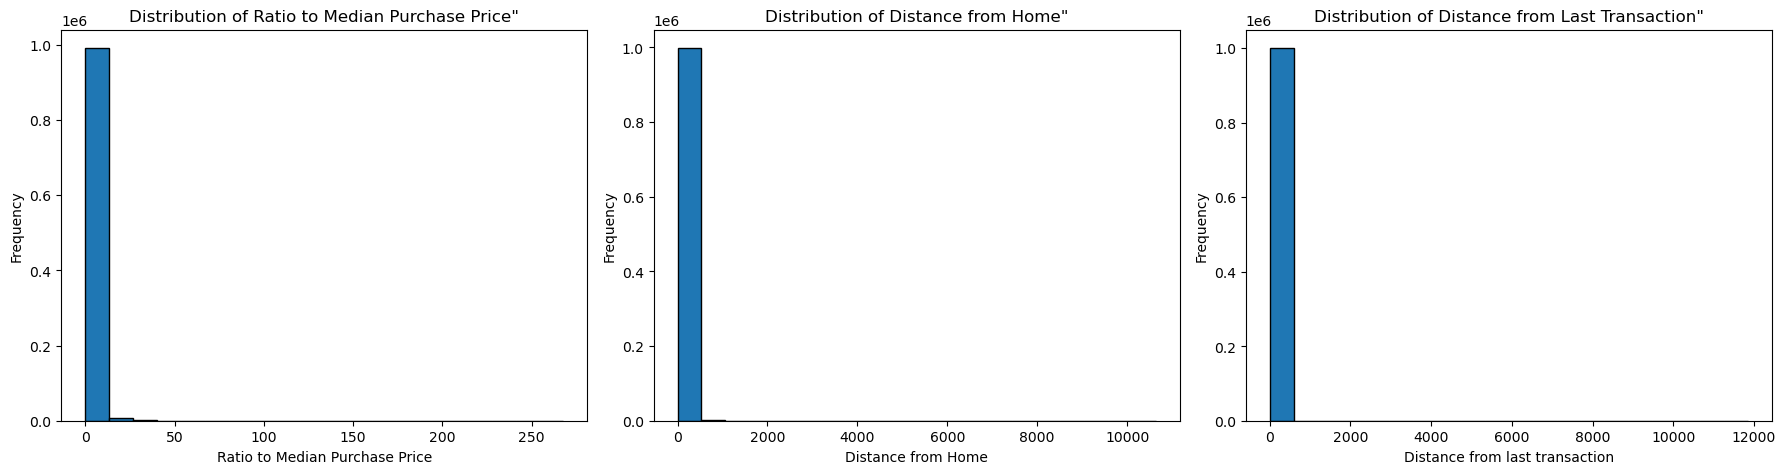

In [ ]:
# Creating three histograms to visualize the distrubution of the three conitnuous numetical columns

# Create a figure with 3 subplots side-by-side
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Histogram for ration to median purchase price
credit_transactions_df['ratio_to_median_purchase_price'].hist(bins=20, grid=False, edgecolor='black', ax=axes[0])
axes[0].set_title('Distribution of Ratio to Median Purchase Price"')
axes[0].set_xlabel("Ratio to Median Purchase Price")
axes[0].set_ylabel("Frequency")


# Histogram for distance from homw
credit_transactions_df['distance_from_home'].hist(bins=20, grid=False, edgecolor='black', ax=axes[1])
axes[1].set_title('Distribution of Distance from Home"')
axes[1].set_xlabel("Distance from Home")
axes[1].set_ylabel("Frequency")

# Histogram for distance from last transaction
credit_transactions_df['distance_from_last_transaction'].hist(bins=20, grid=False, edgecolor='black', ax=axes[2])
axes[2].set_title('Distribution of Distance from Last Transaction"')
axes[2].set_xlabel("Distance from last transaction")
axes[2].set_ylabel("Frequency")

# Adjust layout to prevent overlapping
plt.tight_layout()
plt.show()

<div style="background-color: lightblue; padding: 10px; color: black; font-size: 16px;">
The histograms showing the distribution of the three variables disucssed confirm that these continuous variables are highly right-skewed. Most of the values are near zero but there are several extremely large values in the dataset.
</div>

### Boxplots

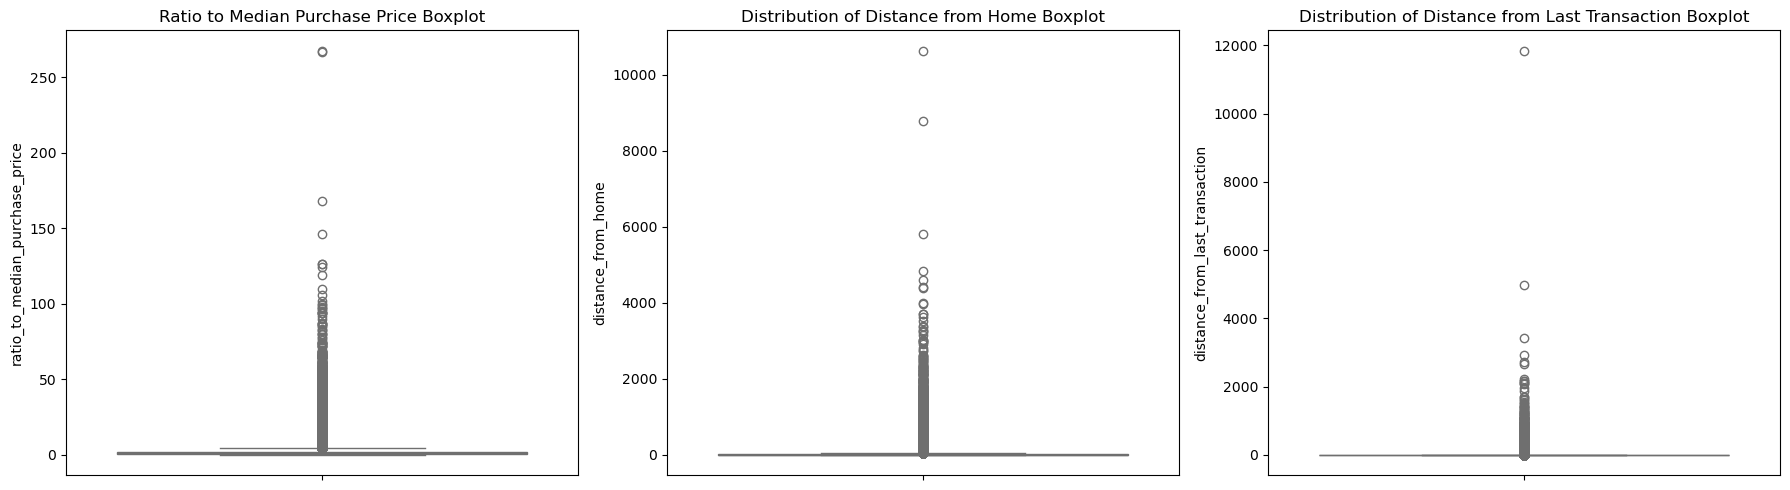

In [ ]:
# Creating three boxplots to visualize the distrubution of the three conitnuous numetical columns

# Create a figure with 3 subplots side-by-side
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Histogram for ration to median purchase price
sns.boxplot(y=credit_transactions_df['ratio_to_median_purchase_price'], ax=axes[0], color='skyblue')
axes[0].set_title("Ratio to Median Purchase Price Boxplot")

# Histogram for distance from homw
sns.boxplot(y=credit_transactions_df['distance_from_home'], ax=axes[1], color='skyblue')
axes[1].set_title("Distribution of Distance from Home Boxplot")

# Histogram for distance from last transaction
sns.boxplot(y=credit_transactions_df['distance_from_last_transaction'], ax=axes[2], color='skyblue')
axes[2].set_title("Distribution of Distance from Last Transaction Boxplot")


# Adjust layout to prevent overlapping
plt.tight_layout()
plt.show()

<div style="background-color: lightblue; padding: 10px; color: black; font-size: 16px;">
The presence of these extreme values is further confirmed with these boxplots that show a large number of numbers beyond the whisters.
</div>

## Statistical Outlier Detection Techniques

<div style="background-color: lightblue; padding: 10px; color: black; font-size: 16px;">
Once we are aware of the distribution of the continuous variables, we can now determine which outlier detection method to use between Z-scores and IQR as our statistical outlier detection technique. The Z-score method assumes that the data are almost normally distributed, which during the previous stage we realized this is not the case as our data has extremely long tails. Since Interquartile Range (IQR) is  based on quartiles rather than the mean and standard deviation (which are sensitive to extreme values), it is much less sensitive to non-normal distributions and therefore, the IQR method was selected as the statistical outlier detection technique here.

</div>

### IQR Code

In [ ]:
# Creating a copy of the dataframe in case changes have to be made to the dataframe, I don't want it to affect the main dataframe
credit_transactions_df_cp = credit_transactions_df.copy()

In [ ]:
X = credit_transactions_df[continuous_columns]

# Create an empty DataFrame to store IQR outlier flags
iqr_mask = pd.DataFrame(False, index=X.index, columns=X.columns)

# Calculate IQR outliers for each variable
for feature in X.columns:

    # Calculate Quartiles
    Q1 = X[feature].quantile(0.25)
    Q3 = X[feature].quantile(0.75)

    # Calculate interquartile range
    IQR = Q3 - Q1

    # Calculate lower and upper bounds using quartile and IQR values calculated
    lower_bound = Q1 - (1.5 * IQR)
    upper_bound = Q3 + (1.5 * IQR)

    # Determine outliers for this variable
    iqr_mask[feature] = ((X[feature] < lower_bound) | (X[feature] > upper_bound))

# Count how the number of variables considered outlier for each transaction
iqr_outlier_count = iqr_mask.sum(axis=1)

# Identify transactions that contain at least one IQR outlier
iqr_outliers = np.where(iqr_outlier_count > 0)[0]

print("Number of IQR outlier transactions:", len(iqr_outliers))

Number of IQR outlier transactions: 281250


In [ ]:
fraudulent_outliers = sum(credit_transactions_df.iloc[iqr_outliers]["fraud"] == 1)

non_fraudulent_outliers = sum(credit_transactions_df.iloc[iqr_outliers]["fraud"] == 0)

print("Detected IQR outliers:", len(iqr_outliers))
print("Fraudulent transactions detected as outliers:", fraudulent_outliers)
print("Non-fraudulent transactions detected as outliers:", non_fraudulent_outliers)

Detected IQR outliers: 281250
Fraudulent transactions detected as outliers: 78363
Non-fraudulent transactions detected as outliers: 202887


In [ ]:
# calculating the fraud rate to get a more meanningful value for later comparison
iqr_fraud_rate = fraudulent_outliers / len(iqr_outliers) * 100
print(f"IQR Fraud Rate: {iqr_fraud_rate:.2f}%")

IQR Fraud Rate: 27.86%


<div style="background-color: lightblue; padding: 10px; color: black; font-size: 16px;">
This shows that around 28% of all of the transactions that were identified as IQR outliers were fraudenlent transactions. This indicates that the majority of the detected outliers are legitimate transactions. Therefore, many of the unusual observations do not necessarily correspond to a fraudulent activity.
</div>

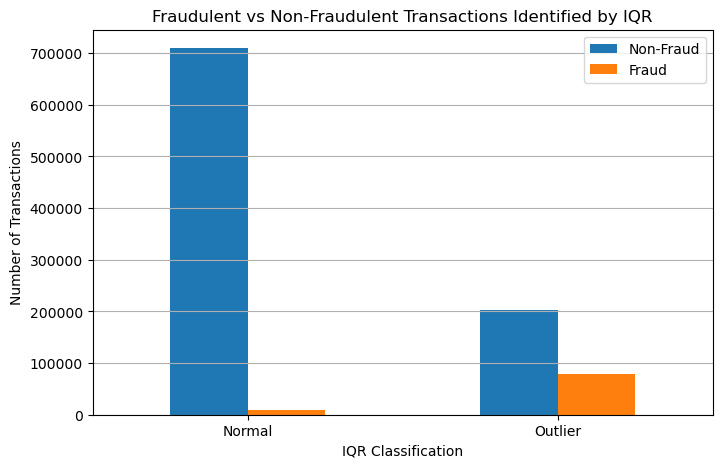

In [ ]:
# Create an IQR outlier flag
credit_transactions_df_cp["iqr_outlier"] = 0
credit_transactions_df_cp.loc[iqr_outliers, "iqr_outlier"] = 1

# Compare IQR classifications with fraud labels
iqr_summary = pd.crosstab(
    credit_transactions_df_cp["iqr_outlier"],
    credit_transactions_df_cp["fraud"]
)

iqr_summary.index = ["Normal", "Outlier"]
iqr_summary.columns = ["Non-Fraud", "Fraud"]

# Plot
iqr_summary.plot(kind="bar",figsize=(8,5))

plt.xlabel("IQR Classification")
plt.ylabel("Number of Transactions")
plt.title("Fraudulent vs Non-Fraudulent Transactions Identified by IQR")
plt.xticks(rotation=0)
plt.grid(axis="y")

plt.show()

<div style="background-color: lightblue; padding: 10px; color: black; font-size: 16px;">
This chart shows a good comparison of the amount of transactions identified as outliers versus normal detected by the IQR method. As can be seen the number of outliers detected is less than half of the normal transactions. Additionally, we can see how this chart conforms our finding of about 28% of outliers being detected as fraudulent.
</div>

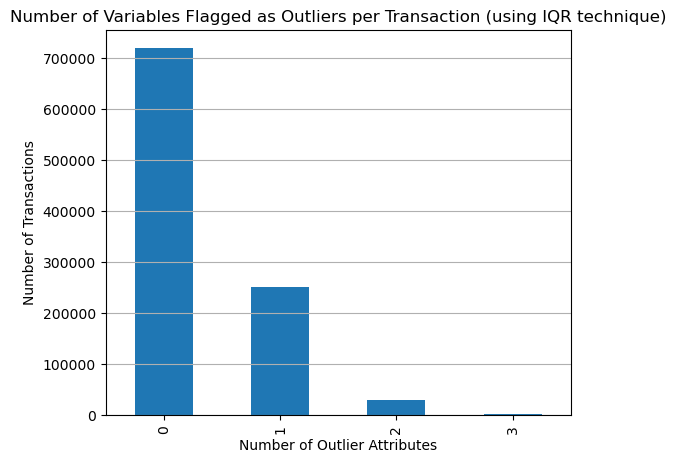

In [ ]:
plt.figure(figsize=(6,5))

iqr_outlier_count.value_counts().sort_index().plot(kind="bar")

plt.xlabel("Number of Outlier Attributes")

plt.ylabel("Number of Transactions")

plt.title("Number of Variables Flagged as Outliers per Transaction (using IQR technique)")

plt.grid(axis="y")

plt.show()

<div style="background-color: lightblue; padding: 10px; color: black; font-size: 16px;">
This bar chart shows what is the distribution of the outlier attributes. This means that in the outliers detected, how many of these transactions had one attribute identified as outlier, how many had two and how many had all three continuous varaibles identified as outliers at once. As can be seen, a few transactions contained multiple outlier variables.
</div>

## Proximity-based methods

### Standardization

<div style="background-color: lightblue; padding: 10px; color: black; font-size: 16px;">
Since we are using distance-based methods here, we will need to normalize the data first. One of the algorithms we will use here is the K-nearest Neighbour (KNN) algorithm which is a distance-based algorithm. Since these varaibles are in different numerical range, for this algorithm to work correctly we will need to standardize the variables first and make sure that all variables contribute equally to the distance calculations and prevent varaibles with larher ranges to affect the result.
</div>

In [ ]:
from sklearn.preprocessing import StandardScaler

X = credit_transactions_df[continuous_columns]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

### K-Nearest Neighbour

<div style="background-color: lightblue; padding: 10px; color: black; font-size: 16px;">
The K-Nearest Neighbours (KNN) method identifies outliers by measuring the average distance between each observation and its nearest neighbours. Observations that are located far from their neighbours are considered potential outliers.
</div>

<div style="background-color: lightblue; padding: 10px; color: black; font-size: 16px;">
We need to determine the threshold for the outlier. We will choose 95 (same as what we did in class). This means that transactions with average distance above the 95th percentile will be classified as outliers. This is to find the most extreme 5% of observations and avoid false posisitives as much as possible.
</div>

In [ ]:
# Set number of nearest neighbours
k = 5

knn = NearestNeighbors(n_neighbors=k)

knn.fit(X_scaled)

# Calculate the distances to nearest neighbors
distances, indices = knn.kneighbors(X_scaled)

# Average distance to k neighbors
knn_score = distances.mean(axis=1)

# Define thresholdto to 95 to get the top 5% most isolated transactions
threshold = np.percentile(knn_score, 95)

# Identify outliers
knn_outliers = np.where(knn_score > threshold)[0]

print("Number of KNN outliers:", len(knn_outliers))

Number of KNN outliers: 50000


In [ ]:
knn_fraudulent_outliers = sum(credit_transactions_df.iloc[knn_outliers]["fraud"] == 1)

knn_non_fraudulent_outliers = sum(credit_transactions_df.iloc[knn_outliers]["fraud"] == 0)

print("Detected KNN outliers:", len(knn_outliers))
print("Fraudulent transactions detected as outliers:", knn_fraudulent_outliers)
print("Non-fraudulent transactions detected as outliers:", knn_non_fraudulent_outliers)

Detected KNN outliers: 50000
Fraudulent transactions detected as outliers: 22305
Non-fraudulent transactions detected as outliers: 27695


In [ ]:
# calculating the fraud rate to get a more meanningful value for later comparison
knn_fraud_rate = knn_fraudulent_outliers / len(knn_outliers) * 100
print(f"KNN Fraud Rate: {knn_fraud_rate:.2f}%")

KNN Fraud Rate: 44.61%


<div style="background-color: lightblue; padding: 10px; color: black; font-size: 16px;">
This shows that around 45% of the outliers determined by KNN technique were fraudelent transactions. This indicates a little over half of the outliers identified by this technique are legitimate transactions.
</div>

<div style="background-color: lightblue; padding: 10px; color: black; font-size: 16px;">
This  
</div>

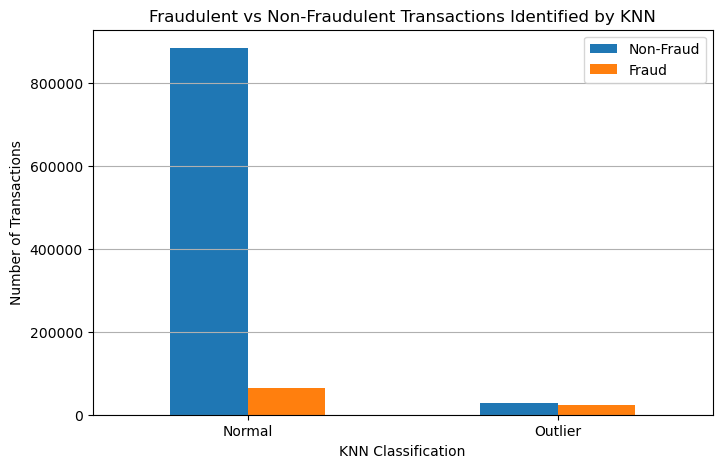

In [ ]:
# Create a KNN outlier flag
credit_transactions_df_cp["knn_outlier"] = 0
credit_transactions_df_cp.loc[knn_outliers, "knn_outlier"] = 1

# Compare with fraud
knn_summary = pd.crosstab(
    credit_transactions_df_cp["knn_outlier"],
    credit_transactions_df_cp["fraud"]
)

knn_summary.index = ["Normal", "Outlier"]
knn_summary.columns = ["Non-Fraud", "Fraud"]

knn_summary.plot(
    kind="bar",
    figsize=(8,5)
)

plt.xlabel("KNN Classification")
plt.ylabel("Number of Transactions")
plt.title("Fraudulent vs Non-Fraudulent Transactions Identified by KNN")
plt.xticks(rotation=0)

plt.grid(axis="y")

plt.show()

<div style="background-color: lightblue; padding: 10px; color: black; font-size: 16px;">
This visualization shows that the number of outliers it detected is significantly lower than the number of normal transactions it detected as expected. The chart also visually supports our finding of around 45% of outliers being fraudulent transactions. This is while a large part of the normal transactions are non-fraud activities, pointing to how we have a class imbalance here. This visualziation also shows that KNN is effective at isolating transactions that are more likely to be fraudulent while still being able to identify relatively few legitimate transactions as outliers.
</div>

### Local Outlier Factor (Density-based)

<div style="background-color: lightblue; padding: 10px; color: black; font-size: 16px;">
For the last outlier detection method, the local outlier factor (LOF) is chosen. This method is a density-based proximity method that identifies values that have a lower local density thatn their neighbouring values. This algoeithm has been desgined for this main purpose of anpmaly detection. Unlike global statistical methods, LOF compares each observation to its local neighbourhood, which makes it effective for identifying local outliers that may not look extreme when considering the entire dataset.
    <br> Also, this method is similar to the previous technique used (KNN) but they answer different questions. KNN looks into how is the transaction from its k-nearest neighours. But LOF looks into if the transaction is less dense than its neighours, so instead of just measuring distance it compares densities.
</div>

<div style="background-color: lightblue; padding: 10px; color: black; font-size: 16px;">
The number of neighbours is set to 20 following this scikti-learn tutorial:
    https://scikit-learn.org/stable/auto_examples/neighbors/plot_lof_outlier_detection.html
    This parameter is set to be greater than the minimum number of observations a cluster will contain but smaller than the maximum number of close by samples that might be local outliers.
</div>

In [ ]:
# Creat the LOF model
lof = LocalOutlierFactor(n_neighbors=20,contamination=0.1)
lof_labels = lof.fit_predict(X_scaled)
lof_outliers = np.where(lof_labels == -1)[0]
print("Number of LOF Outliers:", len(lof_outliers))

Number of LOF Outliers: 100000


In [ ]:
lof_fraudulent_outliers = sum(credit_transactions_df.iloc[lof_outliers]["fraud"] == 1)

lof_non_fraudulent_outliers = sum(credit_transactions_df.iloc[lof_outliers]["fraud"] == 0)

print("Detected KNN outliers:", len(lof_outliers))
print("Fraudulent transactions detected as outliers:", lof_fraudulent_outliers)
print("Non-fraudulent transactions detected as outliers:", lof_non_fraudulent_outliers)

Detected KNN outliers: 100000
Fraudulent transactions detected as outliers: 21400
Non-fraudulent transactions detected as outliers: 78600


In [ ]:
# calculating the fraud rate to get a more meanningful value for later comparison
lof_fraud_rate = lof_fraudulent_outliers / len(lof_outliers) * 100
print(f"LOF Fraud Rate: {lof_fraud_rate:.2f}%")

LOF Fraud Rate: 21.40%


<div style="background-color: lightblue; padding: 10px; color: black; font-size: 16px;">
This shows that 21.4% of the transactions that the LOF found as local outliers were fraudulent. Although most outliers detected were still legitimate transactions. This value is smaller than both the two techniques we looked into before this (IQR and KNN).
</div>

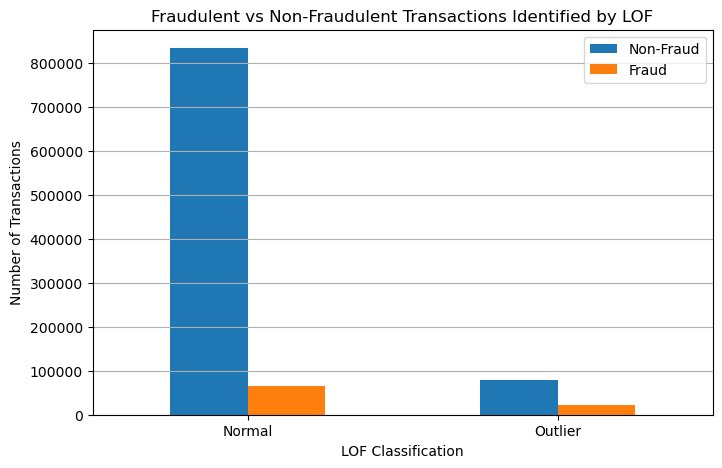

In [ ]:
credit_transactions_df_cp["lof_outlier"] = 0
credit_transactions_df_cp.loc[lof_outliers, "lof_outlier"] = 1

lof_summary = pd.crosstab(
    credit_transactions_df_cp["lof_outlier"],
    credit_transactions_df_cp["fraud"])

lof_summary.index = ["Normal","Outlier"]
lof_summary.columns = ["Non-Fraud","Fraud"]

lof_summary.plot(
    kind="bar",
    figsize=(8,5))

plt.xlabel("LOF Classification")
plt.ylabel("Number of Transactions")
plt.title("Fraudulent vs Non-Fraudulent Transactions Identified by LOF")
plt.xticks(rotation=0)
plt.grid(axis="y")

plt.show()

<div style="background-color: lightblue; padding: 10px; color: black; font-size: 16px;">
Same as the two previous methods, this visualization aso comparese the transactions classified as normal and outliers that LOF was able to identify and separates them into fraudulent and non-fraudulent transactions. Here as well, the majority of the dataset was classified as normal transactions. Additionally, non-fraudulent transactions make up the majority of the detected outliers like the previous methods. A considerable portion of fraudulent transaction appear within the outlier group.
</div>

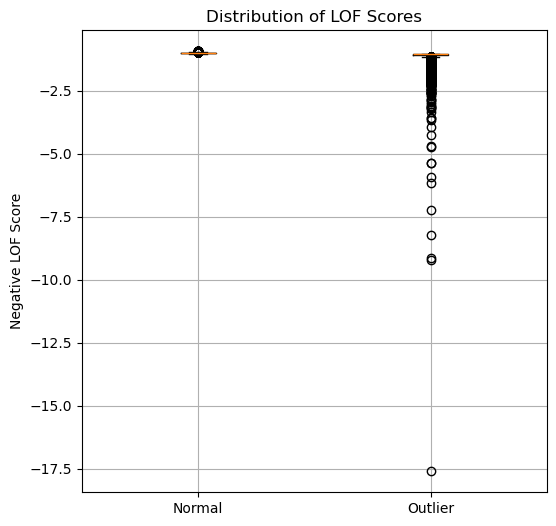

In [ ]:
# Get the LOF scores for every transaction
lof_scores = lof.negative_outlier_factor_

plt.figure(figsize=(6,6))

plt.boxplot(
    [
        lof_scores[lof_labels == 1],
        lof_scores[lof_labels == -1]
    ],
    tick_labels=["Normal","Outlier"]
)

plt.ylabel("Negative LOF Score")
plt.title("Distribution of LOF Scores")

plt.grid(True)

plt.show()

<div style="background-color: lightblue; padding: 10px; color: black; font-size: 16px;">
The boxplot compares the distribution of negative LOF score for normal and outlier transactions identified. Normal transactions have a score that is close to -1 and this shows similar local densities. This is while outliers have more negative scores which shows that they are located in less dense neighbourhoods. This shows that the LOF algorithm is able to successfully separate transactions based on differences in local density.
</div>

## Method Comparision

I believe the most suitable methods depends on our objective. If we want to identify as many potenailly fraudulent transaction as possible, then the IQR method is preferable because it was able to identify the highest number of fraudelent transactions (78,363). However, this high fraud rate came at the cost of identifying a large number of legitimate transactions as outliers which means the technique had low precision. But, if the objective is high precision and producing a smaller set of highly suspicious transactions with a higher chance of most of them being fraudulent, then the KNN method did a better job. Even though KNN detected fewer fraudulent transactions in general (22,305), but 44.61% of the outliers it detected were fraudelent. While IQR and LOF were able to identify 27.86% and 21.4% frauduelent transactions as outliers respectively.

The detected outliers were related to fraudulent transactions because fraudulent activities are often different than normal purchasing patterns. These transactions were identified because they had extreme values (like for purchasing amount), they were located far from the majority of where the other transactions stood, or had much lower local density compared to their neighbouring transactions. For instance, unsually large purchase amounts or transactions that occur much farther then where the customer lives can be identified as outliers by the IQR method, while KNN would idenfity transactions that are far away from other transactions in the feature space. Simialry, LOF identifies transactions as outliers if they are in regions that have lower local density compared ot the sorrounding neighbours.  These unusual characterisitcs make these transactions be considered an outlier


It is important to also note that not every outlier is a fraud and not every fraud is detected as an outlier, legitimate customer behaviours such as making rare large-amount purchases can also be considered as an outlier. That is why outlier detection methods can best act as a pre-screening method that can flag transactions for more review and it should not be used as an ultimate classifier.

# Advanced Association Rule Mining

## Decision Tree

### Split Data

In [ ]:
X = credit_transactions_df.drop(columns=["fraud"])
y = credit_transactions_df["fraud"]

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.20,random_state=42,stratify=y)

In [ ]:
# Printing the size of the training dataset
print("X_train Size:", X_train.shape)
print("y_train Size:", y_train.shape)

X_train Size: (800000, 7)
y_train Size: (800000,)


In [ ]:
# Printing the size of the testing dataset
print("X_test Size:", X_test.shape)
print("y_test Size:", y_test.shape)

X_test Size: (200000, 7)
y_test Size: (200000,)


In [ ]:
# Printing the training dataset columns to make sure that the tree will be trained on correct atttributes
X.columns

Index(['ratio_to_median_purchase_price', 'distance_from_home',
       'distance_from_last_transaction', 'used_chip', 'used_pin_number',
       'repeat_retailer', 'online_order'],
      dtype='object')

### Build the tree

In [ ]:
# Training the tree fully first with no pre-pruning strategy. After that pruning will be used using ccp_alpha (the standard pruning strategy of scikit learn).
tree = DecisionTreeClassifier(random_state=42)

tree.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

In [ ]:
predictions = tree.predict(X_test)

print("Accuracy:", accuracy_score(y_test, predictions))

Accuracy: 0.99998


<div style="background-color: lightblue; padding: 10px; color: black; font-size: 16px;">
As can be seen the accuracy us about 99% which is very high and this value is not really a standard value for an accuracy. Therefore, we can further look into this tree to make sure we don't have problems like overfitting.
</div>

In [ ]:
# Creating a conflusion matrix to see how the tree performed in terms of classifying the labels
cm = confusion_matrix(y_test, predictions)
print(cm)

[[182519      0]
 [     4  17477]]


In [ ]:
# Printing the tree depth and number of nodes to make sure it didn't overfit to have many number of trees
print("Tree depth:", tree.get_depth())
print("Leaves:", tree.get_n_leaves())

Tree depth: 7
Leaves: 37


<div style="background-color: lightblue; padding: 10px; color: black; font-size: 16px;">
The result of the confusion matrix shows that 182519 of the legitimate transactions were correctly classified by the three with zero legitimate transactions misclassfieid, while 17477 of the fraudelent transactions were identified correctly with 4 of them misclassified as legitimate. Additionally, we saw that there were 7 depths of tree with 37 leaves which is not that big. This issue of very high accuracy can be because of the data which is synthtic so we might have data leakage because of that.
</div>

### Prunning the tree

<div style="background-color: lightblue; padding: 10px; color: black; font-size: 16px;">
For pruning we will be using cost complexity pruning. Minimal cost complexity pruning finds the weakest link for nodes through recursion and then the weakest link is given an alpha value which later on these values determine which nodes to prune. The nodes with the smallest alpha are pruned first.

Reference: https://scikit-learn.org/stable/auto_examples/tree/plot_cost_complexity_pruning.html
</div>

In [ ]:
# Calculating the pruning path
path = tree.cost_complexity_pruning_path(X_train, y_train)

ccp_alphas, impurities = path.ccp_alphas, path.impurities

Text(0.5, 1.0, 'Total Impurity vs effective alpha for training set')

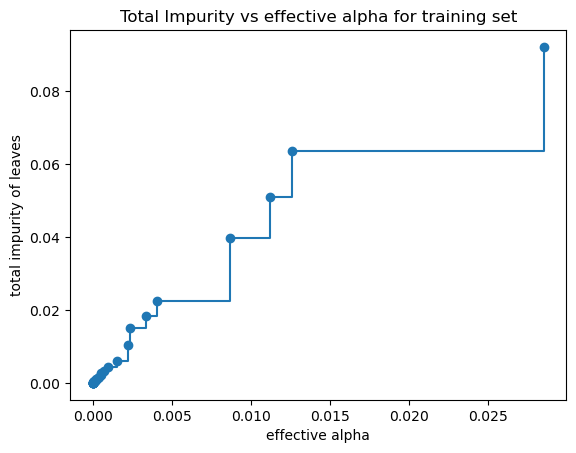

In [ ]:
fig, ax = plt.subplots()
ax.plot(ccp_alphas[:-1], impurities[:-1], marker="o", drawstyle="steps-post")
ax.set_xlabel("effective alpha")
ax.set_ylabel("total impurity of leaves")
ax.set_title("Total Impurity vs effective alpha for training set")

<div style="background-color: lightblue; padding: 10px; color: black; font-size: 16px;">
This visualization shows how the complexity of the decision tree changes as cost-complexity pruning is appplied to it. Each increase in the value of alpha means that one or more branches are removed from the tree and the tree is getting simpler. As can be seen as the alpha increased the impurity also increases. This shows that the pruning process is not so helpful for this decision tree and additional pruning reduces the tree's ability to correctly calssify fraudelent versus non-fraudelent transactions. We can also see that at the beginning the change of impurity was more subtle as alpha increased compared to later on.
</div>

In [ ]:
# After that we traing a decision tree for every ccp_alpha
trees = []
for ccp_alpha in ccp_alphas:
    clf = DecisionTreeClassifier(random_state=42, ccp_alpha=ccp_alpha)
    clf.fit(X_train, y_train)
    trees.append(clf)

print("Number of nodes in the last tree is: {} with ccp_alpha: {}".format(
        trees[-1].tree_.node_count, ccp_alphas[-1]))

Number of nodes in the last tree is: 1 with ccp_alpha: 0.06732837356763001


In [ ]:
# Evaluating each tree / comparing training and testing accuracy
train_scores = [clf.score(X_train, y_train) for clf in trees]
test_scores = [clf.score(X_test, y_test) for clf in trees]

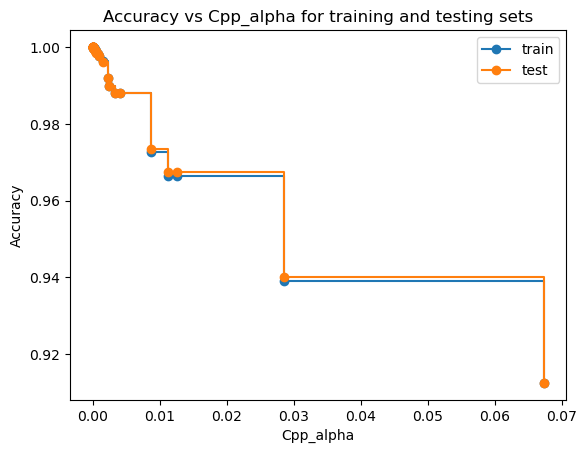

In [ ]:
# Visualization the result
train_scores = [clf.score(X_train, y_train) for clf in trees]
test_scores = [clf.score(X_test, y_test) for clf in trees]

fig, ax = plt.subplots()
ax.set_xlabel("Cpp_alpha")
ax.set_ylabel("Accuracy")
ax.set_title("Accuracy vs Cpp_alpha for training and testing sets")
ax.plot(ccp_alphas, train_scores, marker="o", label="train", drawstyle="steps-post")
ax.plot(ccp_alphas, test_scores, marker="o", label="test", drawstyle="steps-post")
ax.legend()
plt.show()

<div style="background-color: lightblue; padding: 10px; color: black; font-size: 16px;">
This graph shows that as ccp_alpha increases, the testing and training accuracy decrease. As can be seen the ccp_alpha where we have the highest testing and training accuracy is around or equal to 0. We will still calculate the best alpha and use that for training the final tree.
</div>

In [ ]:
# We choose the alpha where the testing accuracy is the highest so we can build the final tree based on it
best_alpha = ccp_alphas[np.argmax(test_scores)]
print("Best alpha: ", best_alpha)

Best alpha:  0.0


<div style="background-color: lightblue; padding: 10px; color: black; font-size: 16px;">
The best alpha is zero as expected which means that the tree is not going to change and its original format was the best already and it was simple enough (with 7 levels of depth and 3 leaves).
</div>

In [ ]:
final_tree = DecisionTreeClassifier(random_state=42, ccp_alpha=best_alpha)
final_tree.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

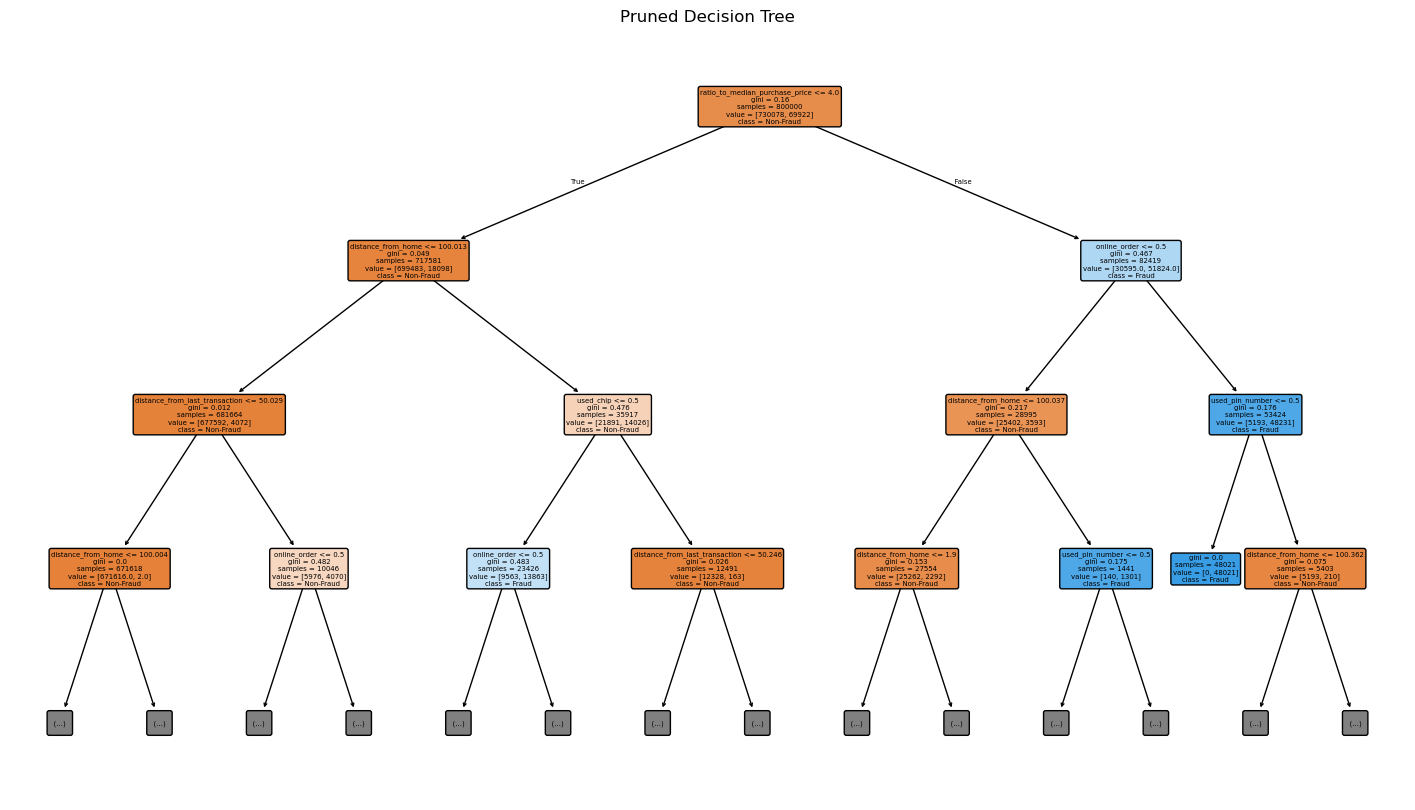

In [ ]:
plt.figure(figsize=(18,10))

plot_tree(
    final_tree,
    feature_names=X.columns,
    class_names=["Non-Fraud","Fraud"],
    filled=True,
    rounded=True,
    max_depth = 3,
    fontsize=5
)

plt.title("Pruned Decision Tree")

plt.show()

## Association Rule Mining

In [ ]:
# Create a copy for association rule mining
credit_df_cpy = credit_transactions_df.copy()

<div style="background-color: lightblue; padding: 10px; color: black; font-size: 16px;">
Before starting the rule mining, we need to discretize the variables. This is because the Apriori algorithm can work with categorical variables in order to create meaningful rules. For our discretizing method for our continuous variables we will be using the equal-frequency binning method, especially that the previous analysis we had showed that the continuous variables have a right-skewed distribution. The binary variables will also be mapped to more interpretable catgories.
</div>

### Discretizing

In [ ]:
# Discretizing continuous variables into categories
# Here the discretization is done using equal-frequency binning so each bin/category gets equal number of values

# Discretizing the distance_from_home_cat variable
credit_df_cpy["distance_from_home_dis"] = pd.qcut(credit_df_cpy["distance_from_home"], q=3,
    labels=["Distance_Home_Low","Distance_Home_Medium","Distance_Home_High"    ])


# Discretizing the distance_from_last_transaction_cat variable
credit_df_cpy["distance_from_last_transaction_dis"] = pd.qcut(credit_df_cpy["distance_from_last_transaction"],q=3,
    labels=["Distance_Last_Low","Distance_Last_Medium","Distance_Last_High"    ])

# Discretizing the ratio_to_median_purchase_price_cat variable
credit_df_cpy["ratio_to_median_purchase_price_dis"] = pd.qcut(credit_df_cpy["ratio_to_median_purchase_price"],q=3,
    labels=["Purchase_Ratio_Low","Purchase_Ratio_Medium","Purchase_Ratio_High"    ])

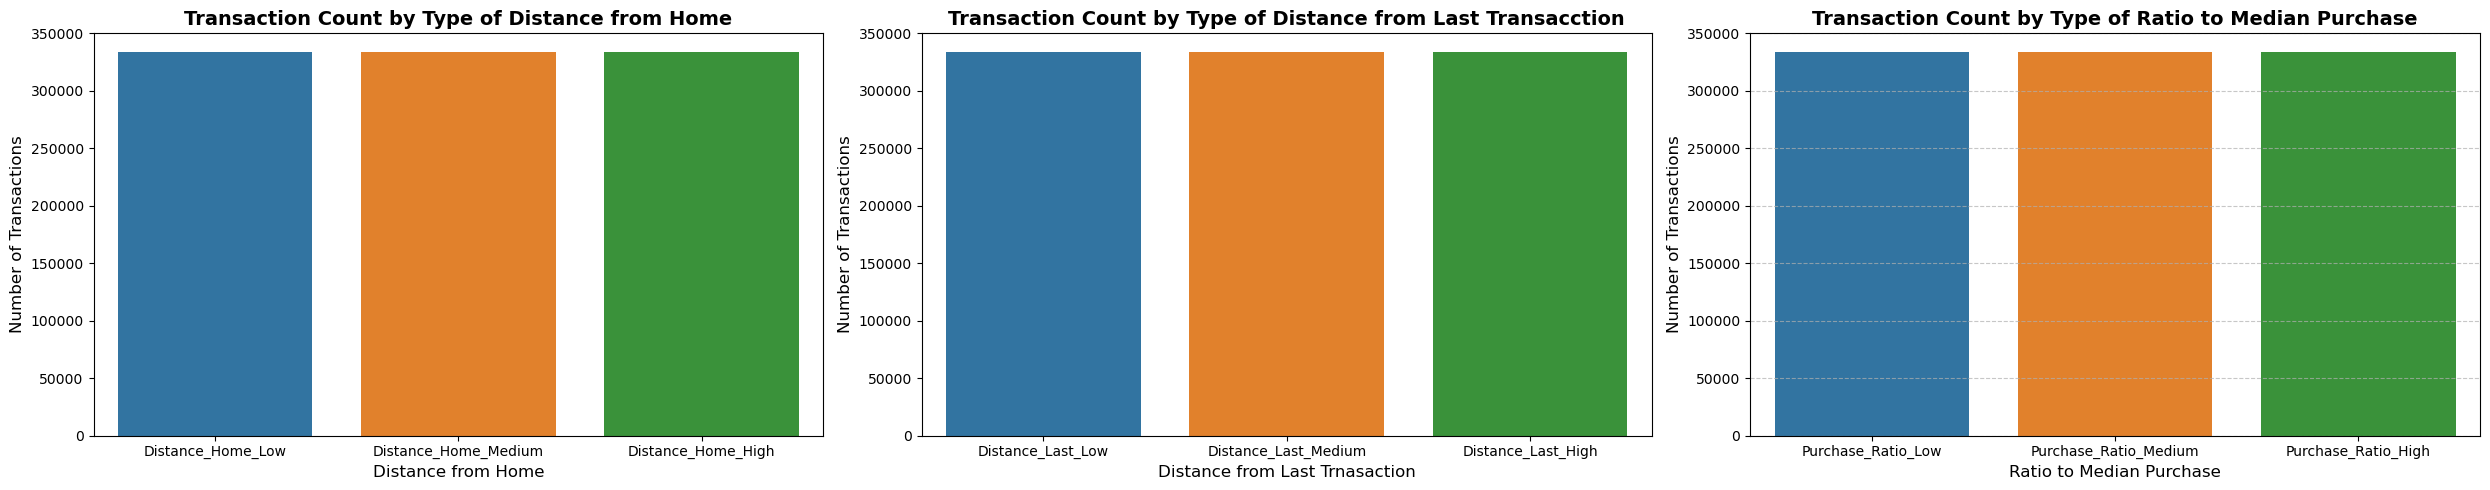

In [ ]:
# Creating three histograms to visualize the distrubution of the three conitnuous numetical columns

# Create a figure with 3 subplots side-by-side
fig, axes = plt.subplots(1, 3, figsize=(25, 5))

# Visualization for distance_from_home_dis
sns.countplot(data=credit_df_cpy, x='distance_from_home_dis', order=['Distance_Home_Low', 'Distance_Home_Medium', 'Distance_Home_High'], hue='distance_from_home_dis',legend=False, ax=axes[0])
axes[0].set_title('Transaction Count by Type of Distance from Home', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Distance from Home', fontsize=12)
axes[0].set_ylabel('Number of Transactions', fontsize=12)

# Visualization for distance_from_last_transaction_dis
sns.countplot(data=credit_df_cpy, x='distance_from_last_transaction_dis', order=['Distance_Last_Low', 'Distance_Last_Medium', 'Distance_Last_High'], hue='distance_from_last_transaction_dis',legend=False, ax=axes[1])
axes[1].set_title('Transaction Count by Type of Distance from Last Transacction', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Distance from Last Trnasaction', fontsize=12)
axes[1].set_ylabel('Number of Transactions', fontsize=12)

# Visualization for ratio_to_median_purchase_price_dis
sns.countplot(data=credit_df_cpy, x='ratio_to_median_purchase_price_dis', order=['Purchase_Ratio_Low', 'Purchase_Ratio_Medium', 'Purchase_Ratio_High'], hue='ratio_to_median_purchase_price_dis',legend=False, ax=axes[2])
axes[2].set_title('Transaction Count by Type of Ratio to Median Purchase', fontsize=14, fontweight='bold')
axes[2].set_xlabel('Ratio to Median Purchase', fontsize=12)
axes[2].set_ylabel('Number of Transactions', fontsize=12)

# Adjust layout to prevent overlapping
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

<div style="background-color: lightblue; padding: 10px; color: black; font-size: 16px;">
As can be seen the equal-frequency binning was applied correctly and each of the categories/bins have equal number of values.
</div>

In [ ]:
# Convert binary variables into descriptive labels
credit_df_cpy["repeat_retailer_dis"] = credit_df_cpy["repeat_retailer"].map({1: "Retailer_Is_Repeated",0: "Retailer_NOT_Repeated"})

credit_df_cpy["used_chip_dis"] = credit_df_cpy["used_chip"].map({1: "Chip_Used",0: "Chip_NOT_Used"})

credit_df_cpy["used_pin_number_dis"] = credit_df_cpy["used_pin_number"].map({1: "PIN_Used",0: "Pin_NOT_Used"})

credit_df_cpy["online_order_dis"] = credit_df_cpy["online_order"].map({1: "Order_Online",0: "Order_NOT_Online"})

credit_df_cpy["fraud_dis"] = credit_df_cpy["fraud"].map({1: "Is_Fraudelent",0: "Not_Fraudelent"})

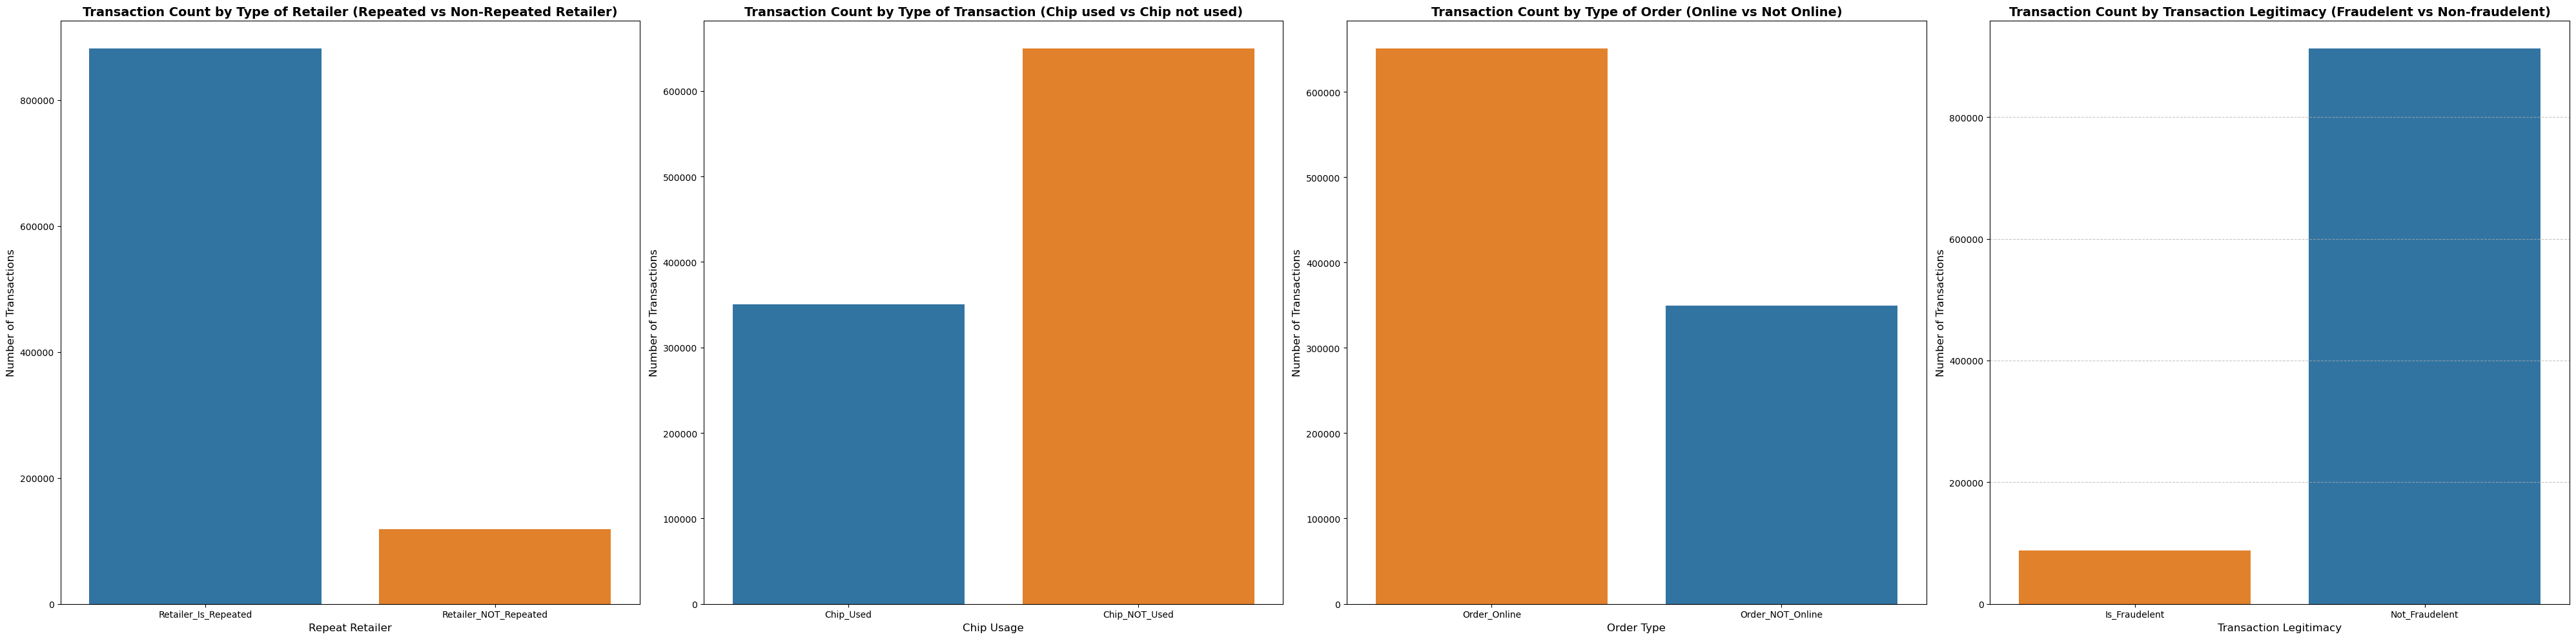

In [ ]:
# Creating three histograms to visualize the distrubution of the three conitnuous numetical columns

# Create a figure with 3 subplots side-by-side
fig, axes = plt.subplots(1, 4, figsize=(40, 10))

# Visualization for repeat_retailer_dis
sns.countplot(data=credit_df_cpy, x='repeat_retailer_dis', order=['Retailer_Is_Repeated', 'Retailer_NOT_Repeated'], hue='repeat_retailer_dis',legend=False, ax=axes[0])
axes[0].set_title('Transaction Count by Type of Retailer (Repeated vs Non-Repeated Retailer)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Repeat Retailer', fontsize=12)
axes[0].set_ylabel('Number of Transactions', fontsize=12)

# Visualization for used_chip_dis
sns.countplot(data=credit_df_cpy, x='used_chip_dis', order=['Chip_Used', 'Chip_NOT_Used'], hue='used_chip_dis',legend=False, ax=axes[1])
axes[1].set_title('Transaction Count by Type of Transaction (Chip used vs Chip not used)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Chip Usage', fontsize=12)
axes[1].set_ylabel('Number of Transactions', fontsize=12)

# Visualization for online_order_dis
sns.countplot(data=credit_df_cpy, x='online_order_dis', order=['Order_Online', 'Order_NOT_Online'], hue='online_order_dis',legend=False, ax=axes[2])
axes[2].set_title('Transaction Count by Type of Order (Online vs Not Online)', fontsize=14, fontweight='bold')
axes[2].set_xlabel('Order Type', fontsize=12)
axes[2].set_ylabel('Number of Transactions', fontsize=12)


# Visualization for fraud_dis
sns.countplot(data=credit_df_cpy, x='fraud_dis', order=['Is_Fraudelent', 'Not_Fraudelent'], hue='fraud_dis',legend=False, ax=axes[3])
axes[3].set_title('Transaction Count by Transaction Legitimacy (Fraudelent vs Non-fraudelent)', fontsize=14, fontweight='bold')
axes[3].set_xlabel('Transaction Legitimacy', fontsize=12)
axes[3].set_ylabel('Number of Transactions', fontsize=12)

# Adjust layout to prevent overlapping
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

<div style="background-color: lightblue; padding: 10px; color: black; font-size: 16px;">
As can be seen the binary variables are correctly discretized into two categories.
</div>

In [ ]:
credit_df_cpy.head()

,ratio_to_median_purchase_price,fraud,distance_from_home,distance_from_last_transaction,used_chip,used_pin_number,repeat_retailer,online_order,distance_from_home_dis,distance_from_last_transaction_dis,ratio_to_median_purchase_price_dis,repeat_retailer_dis,used_chip_dis,used_pin_number_dis,online_order_dis,fraud_dis
0,1.945940,0,57.877857,0.311140,1,0,1,0,Distance_Home_High,Distance_Last_Low,Purchase_Ratio_High,Retailer_Is_Repeated,Chip_Used,Pin_NOT_Used,Order_NOT_Online,Not_Fraudelent
1,1.294219,0,10.829943,0.175592,0,0,1,0,Distance_Home_Medium,Distance_Last_Low,Purchase_Ratio_Medium,Retailer_Is_Repeated,Chip_NOT_Used,Pin_NOT_Used,Order_NOT_Online,Not_Fraudelent
2,0.427715,0,5.091079,0.805153,0,0,1,1,Distance_Home_Low,Distance_Last_Medium,Purchase_Ratio_Low,Retailer_Is_Repeated,Chip_NOT_Used,Pin_NOT_Used,Order_Online,Not_Fraudelent
3,0.362663,0,2.247564,5.600044,1,0,1,1,Distance_Home_Low,Distance_Last_High,Purchase_Ratio_Low,Retailer_Is_Repeated,Chip_Used,Pin_NOT_Used,Order_Online,Not_Fraudelent
4,2.222767,0,44.190936,0.566486,1,0,1,1,Distance_Home_High,Distance_Last_Medium,Purchase_Ratio_High,Retailer_Is_Repeated,Chip_Used,Pin_NOT_Used,Order_Online,Not_Fraudelent


In [ ]:
# Keep the discretzied variables only
credit_df_cpy = credit_df_cpy[
    [
        "distance_from_home_dis",
        "distance_from_last_transaction_dis",
        "ratio_to_median_purchase_price_dis",
        "repeat_retailer_dis",
        "used_chip_dis",
        "used_pin_number_dis",
        "online_order_dis",
        "fraud_dis"
    ]
]

In [ ]:
credit_df_cpy.head()

,distance_from_home_dis,distance_from_last_transaction_dis,ratio_to_median_purchase_price_dis,repeat_retailer_dis,used_chip_dis,used_pin_number_dis,online_order_dis,fraud_dis
0,Distance_Home_High,Distance_Last_Low,Purchase_Ratio_High,Retailer_Is_Repeated,Chip_Used,Pin_NOT_Used,Order_NOT_Online,Not_Fraudelent
1,Distance_Home_Medium,Distance_Last_Low,Purchase_Ratio_Medium,Retailer_Is_Repeated,Chip_NOT_Used,Pin_NOT_Used,Order_NOT_Online,Not_Fraudelent
2,Distance_Home_Low,Distance_Last_Medium,Purchase_Ratio_Low,Retailer_Is_Repeated,Chip_NOT_Used,Pin_NOT_Used,Order_Online,Not_Fraudelent
3,Distance_Home_Low,Distance_Last_High,Purchase_Ratio_Low,Retailer_Is_Repeated,Chip_Used,Pin_NOT_Used,Order_Online,Not_Fraudelent
4,Distance_Home_High,Distance_Last_Medium,Purchase_Ratio_High,Retailer_Is_Repeated,Chip_Used,Pin_NOT_Used,Order_Online,Not_Fraudelent


### Rule Mining Using Apriori Algorithm

In [ ]:
# Convert each row into a transaction (list of categorical items)
transactions = credit_df_cpy.values.tolist()

print(f"Number of transactions: {len(transactions)}")
print("\nExample transaction:")
print(transactions[0])

Number of transactions: 1000000

Example transaction:
['Distance_Home_High', 'Distance_Last_Low', 'Purchase_Ratio_High', 'Retailer_Is_Repeated', 'Chip_Used', 'Pin_NOT_Used', 'Order_NOT_Online', 'Not_Fraudelent']


In [ ]:
# One-hot encoding

# Initialize TransactionEncoder
te = TransactionEncoder()
te_array = te.fit(transactions).transform(transactions)

# Convert boolean array into a dataframe
transaction_df = pd.DataFrame(te_array,columns=te.columns_)

transaction_df.head()

,Chip_NOT_Used,Chip_Used,Distance_Home_High,Distance_Home_Low,Distance_Home_Medium,Distance_Last_High,Distance_Last_Low,Distance_Last_Medium,Is_Fraudelent,Not_Fraudelent,Order_NOT_Online,Order_Online,PIN_Used,Pin_NOT_Used,Purchase_Ratio_High,Purchase_Ratio_Low,Purchase_Ratio_Medium,Retailer_Is_Repeated,Retailer_NOT_Repeated
0,False,True,True,False,False,False,True,False,False,True,True,False,False,True,True,False,False,True,False
1,True,False,False,False,True,False,True,False,False,True,True,False,False,True,False,False,True,True,False
2,True,False,False,True,False,False,False,True,False,True,False,True,False,True,False,True,False,True,False
3,False,True,False,True,False,True,False,False,False,True,False,True,False,True,False,True,False,True,False
4,False,True,True,False,False,False,False,True,False,True,False,True,False,True,True,False,False,True,False


In [ ]:
# Running the apriori algorithm:

# Extracting frequent itemsets
frequent_itemsets = apriori(transaction_df,min_support=0.005,use_colnames=True)

print(f"Frequent itemsets found: {len(frequent_itemsets)}")

frequent_itemsets.head()

Frequent itemsets found: 6320


,support,itemsets
0,0.649601,(Chip_NOT_Used)
1,0.350399,(Chip_Used)
2,0.333334,(Distance_Home_High)
3,0.333333,(Distance_Home_Low)
4,0.333333,(Distance_Home_Medium)


In [ ]:
# Generate association rules based on the frequent itemsets found
rules = association_rules(frequent_itemsets,metric="confidence",min_threshold=0.01)

print(f"Association rules generated: {len(rules)}")

rules.head()

Association rules generated: 252172


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,(Chip_NOT_Used),(Distance_Home_High),0.649601,0.333334,0.216538,0.333340,1.000018,1.0,0.000004,1.000009,0.000051,0.282540,0.000009,0.491476
1,(Distance_Home_High),(Chip_NOT_Used),0.333334,0.649601,0.216538,0.649613,1.000018,1.0,0.000004,1.000033,0.000027,0.282540,0.000033,0.491476
2,(Distance_Home_Low),(Chip_NOT_Used),0.333333,0.649601,0.216615,0.649846,1.000377,1.0,0.000082,1.000699,0.000565,0.282669,0.000698,0.491652
3,(Chip_NOT_Used),(Distance_Home_Low),0.649601,0.333333,0.216615,0.333459,1.000377,1.0,0.000082,1.000188,0.001074,0.282669,0.000188,0.491652
4,(Chip_NOT_Used),(Distance_Home_Medium),0.649601,0.333333,0.216448,0.333201,0.999605,1.0,-0.000085,0.999803,-0.001125,0.282390,-0.000197,0.491273


### Sort by Support

In [ ]:
# Sorting rules by the highest support
support_rules = rules.sort_values(by="support",ascending=False)

support_rules[["antecedents","consequents","support","confidence","lift"]].head(10)

,antecedents,consequents,support,confidence,lift
234,(Pin_NOT_Used),(Not_Fraudelent),0.812262,0.903123,0.989619
235,(Not_Fraudelent),(Pin_NOT_Used),0.812262,0.890056,0.989619
242,(Not_Fraudelent),(Retailer_Is_Repeated),0.804611,0.881672,1.000154
243,(Retailer_Is_Repeated),(Not_Fraudelent),0.804611,0.912738,1.000154
291,(Retailer_Is_Repeated),(Pin_NOT_Used),0.792887,0.899438,1.000051
290,(Pin_NOT_Used),(Retailer_Is_Repeated),0.792887,0.881581,1.000051
3940,"(Not_Fraudelent, Retailer_Is_Repeated)",(Pin_NOT_Used),0.716221,0.890146,0.989719
3943,(Retailer_Is_Repeated),"(Pin_NOT_Used, Not_Fraudelent)",0.716221,0.812469,1.000255
3941,(Pin_NOT_Used),"(Not_Fraudelent, Retailer_Is_Repeated)",0.716221,0.796339,0.989719
3942,(Not_Fraudelent),"(Pin_NOT_Used, Retailer_Is_Repeated)",0.716221,0.784816,0.989821


<div style="background-color: lightblue; padding: 10px; color: black; font-size: 14px;">
The rules were sorted based on the order of their support value which represent how many times transactions with both the antecendent and the consequent appeared together. The formula for this metric is: support = (number of transactions containing the itemset) / (Total number of transactions). The highest rule in the table is (Pin_NOT_Used) -> (Not_Fraudelent) which has a support value of 0.812262 which is very high and shows that these two items appear very frequenctly together.

</div>

### Sort by Confidence

In [ ]:
# Sorting rules by the highest confidence
confidence_rules = rules.sort_values(by="confidence",ascending=False)

confidence_rules[["antecedents","consequents","support","confidence", "lift"]].head(10)

,antecedents,consequents,support,confidence,lift
43120,"(Purchase_Ratio_Low, Order_NOT_Online, Chip_NO...",(Not_Fraudelent),0.025070,1.0,1.095774
38853,"(Purchase_Ratio_Low, Distance_Home_Medium, PIN...",(Retailer_Is_Repeated),0.007309,1.0,1.134384
5053,"(Chip_NOT_Used, PIN_Used, Distance_Home_High)",(Retailer_Is_Repeated),0.021783,1.0,1.134384
21222,"(PIN_Used, Purchase_Ratio_Medium, Distance_Hom...",(Not_Fraudelent),0.011059,1.0,1.095774
38704,"(Pin_NOT_Used, Distance_Home_Medium, Order_Onl...",(Retailer_Is_Repeated),0.126567,1.0,1.134384
251198,"(Distance_Last_Low, Chip_Used, Purchase_Ratio_...","(Not_Fraudelent, Retailer_Is_Repeated)",0.007634,1.0,1.242837
191886,"(Purchase_Ratio_Medium, Pin_NOT_Used, Distance...","(Not_Fraudelent, Distance_Home_Low)",0.007805,1.0,3.240220
21234,"(Not_Fraudelent, PIN_Used, Distance_Home_Medium)",(Retailer_Is_Repeated),0.033519,1.0,1.134384
200744,"(Order_NOT_Online, Purchase_Ratio_Low, Distanc...","(Not_Fraudelent, Retailer_Is_Repeated)",0.008331,1.0,1.242837
191874,"(Purchase_Ratio_Medium, Pin_NOT_Used, Distance...",(Not_Fraudelent),0.007805,1.0,1.095774


<div style="background-color: lightblue; padding: 10px; color: black; font-size: 14px;">
The rules were sorted based on the order of their confidence value, which represents how often the consequent is purchased when the antecedent is purchased. The formula for this metric is: Confidence = Support(antecedent -> consequent)/Support (antecedent). <br>
    The highest rule in this table has a confidence of 1 and represents the following rule: (Purchase_Ratio_Low, Order_NOT_Online, Chip_NOT_Used -> Not_Fraudelent).
<br>


### Sort by Lift

In [ ]:
# Sorting rules by the highest lift
lift_rules = rules.sort_values(by="lift",ascending=False)

lift_rules[["antecedents","consequents","support","confidence","lift"]].head(10)

,antecedents,consequents,support,confidence,lift
161947,"(Pin_NOT_Used, Purchase_Ratio_High, Retailer_N...","(Distance_Home_Low, Is_Fraudelent)",0.007305,0.317774,12.859117
161970,"(Distance_Home_Low, Is_Fraudelent)","(Pin_NOT_Used, Purchase_Ratio_High, Retailer_N...",0.007305,0.295605,12.859117
103470,"(Distance_Home_Low, Is_Fraudelent)","(Pin_NOT_Used, Purchase_Ratio_High, Retailer_N...",0.007166,0.289981,12.698952
103447,"(Pin_NOT_Used, Purchase_Ratio_High, Retailer_N...","(Distance_Home_Low, Is_Fraudelent)",0.007166,0.313817,12.698952
103454,"(Distance_Home_Low, Chip_NOT_Used, Is_Fraudelent)","(Pin_NOT_Used, Purchase_Ratio_High, Retailer_N...",0.007166,0.417259,11.780977
103463,"(Pin_NOT_Used, Purchase_Ratio_High, Retailer_N...","(Distance_Home_Low, Chip_NOT_Used, Is_Fraudelent)",0.007166,0.202327,11.780977
72626,"(Distance_Home_Low, Is_Fraudelent)","(Purchase_Ratio_High, Retailer_NOT_Repeated, O...",0.007319,0.296172,11.580524
72625,"(Purchase_Ratio_High, Retailer_NOT_Repeated, O...","(Distance_Home_Low, Is_Fraudelent)",0.007319,0.286178,11.580524
161968,"(Purchase_Ratio_High, Retailer_NOT_Repeated, O...","(Pin_NOT_Used, Distance_Home_Low, Is_Fraudelent)",0.007305,0.285630,11.571483
161949,"(Pin_NOT_Used, Distance_Home_Low, Is_Fraudelent)","(Purchase_Ratio_High, Retailer_NOT_Repeated, O...",0.007305,0.295941,11.571483


<div style="background-color: lightblue; padding: 10px; color: black; font-size: 14px;">
The rules were sorted based on the order of their lift value, which measures how much more likely the antecedent and consequent are to happen together compared to a random chance. The formula for lift is: Lift = Confidence (anticedent -> consequent) / Support(consequent). The highest rule
here is the pattern Pin_NOT_Used, Purchase_Ratio_High, Retailer_NOT_Repeated -> Distance_Home_Low, Is_Fraudelent which has a lift of 12.85 which is a very high value and shows a much stronger association than expected.

</div>

## Mining Intesresting Rare Patterns

<div style="background-color: lightblue; padding: 10px; color: black; font-size: 16px;">
We will now have to find the correct thresholds that would give us the rare patterns. For this we would first look into the distribution of each of the metrics for this dataset. Based on this information, we now have to define what we consider as 'rare' for each of these metrics.
</div>

In [ ]:
rules[["support","confidence","lift"]].describe()

,support,confidence,lift
count,252172.000000,252172.000000,252172.000000
mean,0.021463,0.215788,1.157359
std,0.027236,0.223786,0.551529
min,0.005007,0.010015,0.286124
25%,0.007910,0.067306,0.992978
50%,0.012983,0.120223,1.008501
75%,0.022830,0.302500,1.124585
max,0.812262,1.000000,12.859117


<div style="background-color: lightblue; padding: 10px; color: black; font-size: 16px;">
Since rare patterns are expected to appear infrequently, the support threshold for rare patterns was selected using the 1st percentile of the support distributions. This only keeps the lower 1% of the support values, which makes sure that the rules left are the least frequently occuring rules while they remain above the minimum support threshold that was used in the Apriori algorithm earlier.
</div>

In [ ]:
rare_support = rules["support"].quantile(0.01)
print(rare_support)

0.005181


<div style="background-color: lightblue; padding: 10px; color: black; font-size: 16px;">
The threshold selected for this confidence was from the 75th percentile of the confidence distribution so only the rules that have an above-average reliability of happening would be kept. This along with the support value chosen in the previous cell will make sure that the rare patterns identified are not only infrequent but also reliable.
</div>

In [ ]:
rare_confidence = rules["confidence"].quantile(0.75)
print(rare_confidence)

0.3024995595328328


<div style="background-color: lightblue; padding: 10px; color: black; font-size: 16px;">
Lastly, lift measures how much more likely two items are to be appear together compared to a random chance. Since lift values above one show that there is a positive association between the items, a lift value of 1.2 was selected to exclude possible weak positive associations. This ensures that the rare patterns selected have a meaningful relationship rather than random occurence.
</div>

In [ ]:
rare_lift = 1.2

In [ ]:
# Filter for rare (low support), confidence, and strong lift rules
rare_rules = rules[(rules['support'] < rare_support) & (rules['confidence'] >= rare_confidence) & (rules['lift'] > rare_lift)]

print(f"Number of rare rules: {len(rare_rules)}")

Number of rare rules: 135


In [ ]:
rare_rules = rare_rules.sort_values(
    by=["support","lift","confidence"],
    ascending=[True,False,False]
)
rare_rules.head(10)

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
131508,"(Distance_Last_Low, Chip_Used, Order_NOT_Onlin...","(Not_Fraudelent, Retailer_NOT_Repeated)",0.013667,0.107986,0.005007,0.366357,3.392633,1.0,0.003531,1.407755,0.715016,0.042925,0.289649,0.206362
131534,"(Chip_Used, Order_NOT_Online, Retailer_NOT_Rep...","(Distance_Last_Low, Not_Fraudelent, Distance_H...",0.014671,0.103362,0.005007,0.341286,3.301847,1.0,0.003491,1.361194,0.707519,0.044300,0.265351,0.194863
131528,"(Distance_Last_Low, Order_NOT_Online, Retailer...","(Chip_Used, Distance_Home_Low, Not_Fraudelent)",0.013903,0.109180,0.005007,0.360138,3.298572,1.0,0.003489,1.392207,0.706663,0.042405,0.281716,0.202999
131514,"(Distance_Last_Low, Not_Fraudelent, Order_NOT_...","(Chip_Used, Distance_Home_Low)",0.013067,0.116718,0.005007,0.383179,3.282947,1.0,0.003482,1.431991,0.704603,0.040127,0.301671,0.213039
131511,"(Distance_Last_Low, Chip_Used, Not_Fraudelent,...","(Distance_Home_Low, Order_NOT_Online)",0.013138,0.116226,0.005007,0.381108,3.279027,1.0,0.003480,1.427994,0.704284,0.040263,0.299717,0.212094
131509,"(Distance_Last_Low, Chip_Used, Order_NOT_Onlin...","(Not_Fraudelent, Distance_Home_Low)",0.005007,0.308621,0.005007,1.000000,3.240220,1.0,0.003462,inf,0.694858,0.016224,1.000000,0.508112
131525,"(Distance_Last_Low, Chip_Used, Retailer_NOT_Re...","(Not_Fraudelent, Order_NOT_Online, Distance_Ho...",0.013974,0.113654,0.005007,0.358308,3.152624,1.0,0.003419,1.381265,0.692481,0.040833,0.276026,0.201182
51025,"(Distance_Last_Low, Chip_Used, Order_NOT_Onlin...",(Retailer_NOT_Repeated),0.013667,0.118464,0.005007,0.366357,3.092559,1.0,0.003388,1.391219,0.686019,0.039387,0.281206,0.204311
131501,"(Distance_Last_Low, Chip_Used, Order_NOT_Onlin...",(Retailer_NOT_Repeated),0.013667,0.118464,0.005007,0.366357,3.092559,1.0,0.003388,1.391219,0.686019,0.039387,0.281206,0.204311
51034,"(Distance_Last_Low, Order_NOT_Online, Retailer...","(Chip_Used, Distance_Home_Low)",0.013903,0.116718,0.005007,0.360138,3.085540,1.0,0.003384,1.380426,0.685437,0.039860,0.275586,0.201518


### Summary of Findings

<div style="background-color: lightblue; padding: 10px; color: black; font-size: 16px;">
Looking into the top 10 rare patterns, we can see that there are several recurring characterisitcs of fraudelent transactions. We can see that the Order_Online attribute is present in either the anteedent or consequent of almost every rule. This shows that among the rare transaction patterns, online purchases are a common characteristic.  Chip_NOT_Used also appears repeatedly across the rules. This indicates that many of these transactions did not use chip authentication. We can also see that the most of the rules include Is_Fraudulent as part of the consequent which shows that these uncommon rules are assoficated with fraudulent activity. Additionally, many rules include Distance_Home_Low as well as Distance_Last_Low which shows that these frauds often happer close to the cardholder's home or closer to the location of the previous transaction. Repeated retaulers also appear in several of the top rules. These combinations have a support of 0.005 (0.5%) which means that even though these patterns occur rarely (0.5%), their high confidence and lift shows that they have are meaningful and non-random.
</div>

## Mining Interesting Negative Patterns

<div style="background-color: lightblue; padding: 10px; color: black; font-size: 16px;">
From the distributions we saw in the previous step we know that 25% of the rules already have lift less than 0.993 which means there are a number of negative patterns. Negative association rules should represent patterns that are common and reliable that occur less frequently together than expected by chance. This is why instead of low support values, higher support and confidence thresholds were used. The 75th percentile was selected for both the support and the confidence thresholds so that only the top 25% of the most frequent and most relaible rules are kept.
</div>

In [ ]:
negative_support = rules["support"].quantile(0.75)
print(negative_support)

0.02283


In [ ]:
negative_confidence = rules["confidence"].quantile(0.75)
print(negative_confidence)

0.3024995595328328


<div style="background-color: lightblue; padding: 10px; color: black; font-size: 16px;">
Even though negative association rules are defined as having a lift value less than 1, when this rule was used (rules['lif']<1), many of the negative associated rules created had lift values that were extremely close to one which showed a negative relationship that wasn't very strong. In order to look into more meaningful negative associations, a smaller threshold for lift was used (0.7). This threshold identifies rules whose antecedent and consequent occur at least 30% less frequently than expected.
</div>

In [ ]:
negative_lif = 0.7

In [ ]:
# Filter for support, confidence, and negative lift rules
negative_rules = rules[(rules['support'] > negative_support) & (rules['confidence'] >negative_confidence) & (rules['lift'] < negative_lif)]

print(f"Number of negative rules: {len(negative_rules)}")

Number of negative rules: 52


In [ ]:
negative_rules = negative_rules.sort_values(
    by=["lift", "confidence", "support"],
    ascending=[True, False, False]
)
negative_rules.head(10)

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
162374,"(Pin_NOT_Used, Distance_Home_Low, Purchase_Rat...","(Not_Fraudelent, Retailer_Is_Repeated)",0.065110,0.804611,0.028786,0.442113,0.549475,1.0,-0.023602,0.350231,-0.467242,0.034231,-1.855261,0.238945
162399,"(Distance_Home_Low, Purchase_Ratio_High, Order...","(Pin_NOT_Used, Not_Fraudelent, Retailer_Is_Rep...",0.072239,0.716221,0.028786,0.398483,0.556369,1.0,-0.022953,0.471772,-0.462208,0.037893,-1.119668,0.219337
73367,"(Distance_Home_Low, Purchase_Ratio_High, Order...","(Not_Fraudelent, Retailer_Is_Repeated)",0.072239,0.804611,0.033314,0.461164,0.573151,1.0,-0.024810,0.362613,-0.445285,0.039493,-1.757762,0.251284
92886,"(Distance_Home_High, Pin_NOT_Used, Purchase_Ra...",(Not_Fraudelent),0.042203,0.912597,0.024440,0.579106,0.634569,1.0,-0.014074,0.207660,-0.375487,0.026269,-3.815558,0.302943
181716,"(Distance_Home_High, Pin_NOT_Used, Purchase_Ra...",(Not_Fraudelent),0.042203,0.912597,0.024440,0.579106,0.634569,1.0,-0.014074,0.207660,-0.375487,0.026269,-3.815558,0.302943
73624,"(Pin_NOT_Used, Distance_Home_Low, Purchase_Rat...","(Not_Fraudelent, Retailer_Is_Repeated)",0.099869,0.804611,0.051010,0.510769,0.634803,1.0,-0.029346,0.399380,-0.389917,0.059768,-1.503881,0.287083
104981,"(Pin_NOT_Used, Distance_Home_Low, Purchase_Rat...","(Not_Fraudelent, Retailer_Is_Repeated)",0.064614,0.804611,0.033037,0.511298,0.635460,1.0,-0.018952,0.399812,-0.380149,0.039509,-1.501175,0.276179
162392,"(Not_Fraudelent, Distance_Home_Low, Purchase_R...","(Pin_NOT_Used, Retailer_Is_Repeated, Order_Onl...",0.087605,0.515838,0.028786,0.328589,0.637000,1.0,-0.016404,0.721111,-0.384455,0.050092,-0.386750,0.192196
104993,"(Pin_NOT_Used, Distance_Home_Low, Purchase_Rat...","(Not_Fraudelent, Retailer_Is_Repeated, Chip_NO...",0.099869,0.515500,0.033037,0.330803,0.641714,1.0,-0.018445,0.724002,-0.382820,0.056732,-0.381211,0.197445
92898,"(Chip_NOT_Used, Order_Online, Purchase_Ratio_H...","(Pin_NOT_Used, Not_Fraudelent)",0.046861,0.812262,0.024440,0.521542,0.642086,1.0,-0.013623,0.392382,-0.369017,0.029281,-1.548539,0.275816


### Summary of Findings

<div style="background-color: lightblue; padding: 10px; color: black; font-size: 16px;">
    Based on the thresholds set to get the strongest negative association rules, there were 52 rules identified. Thse rules indicate that fradudulent transactions usually have a negative relationship with characteristics that are associated with secure and in-person purchases. From these two 10 rules we can see that the most common antecedents are offline transaction (Order_NOT_Online), PIN verification (PIN_Used), chip used (Chip_Used), and transactions that occur close to the cardholder's home (Distance_Home_Low). These top 10 rules have lift values from about 0.55 to 0.64 which shows that they occur around 40% less frequently than expected. This shows that these transactions are negatively associated with fraud and may represent legitimate purchasing rather than fraudulent activities.
</div>

## Mining Interesting Positive Rules

<div style="background-color: lightblue; padding: 10px; color: black; font-size: 16px;">
The initial association rule mining process generated a large number of rules (111996). To identify the most meaningful and actionable patterns, the distributions of support, confidence, and lift were examined. Thresholds were then selected based on the observed distributions to retain only the strongest positive associations.
</div>

<div style="background-color: lightblue; padding: 10px; color: black; font-size: 16px;">
Support measures how frequently an association rule occurs in the dataset. For the positive association rules, a relatively high support threshold was selected which corresponds to the 75th percentile (2.28%) of support value in the datset in order to retain rules that occur frequently and therefore can present meaningful patterns. Rules that have very low support may be happning because of chance or might be a rare behvaiour (as seen earlier in the rare patterns).  A higher value was not chosen because it might be removing many meaningful transactions. Also, even though based on the table with sorted lift value, many of the strong rules had a very low support, we still kept the threshold at 75th percential to make sure that the selected rules had patterns that occured frequently enough to be meaningful.
</div>

In [ ]:
positive_support = rules["support"].quantile(0.75)
print(positive_support)

0.02283


<div style="background-color: lightblue; padding: 10px; color: black; font-size: 16px;">
Confidence measures the probability that the consequent happens when the antecedent happens. Although rules that had a confidence close to 100% appear strong as they have high lift values (as we saw in the table sorted by confidence value), the results showed that many of these rules predicted very common consequents such as Not_Fraudulent and therefore, did not really demonstrate an interesting relationship. Therefore, instead of choosing a very high value for confidence, the 75th percentile (30.25%) was selected for this metric's threshold in order to keep only the most reliable quarter of the rules generated and remove the weaker rules.
</div>

In [ ]:
positive_confidence = rules["confidence"].quantile(0.75)
print(positive_confidence)

0.3024995595328328


<div style="background-color: lightblue; padding: 10px; color: black; font-size: 16px;">
Lift measures the strength of the association between the antecedent and consequent compared with random chance and that is why it is a great metric to determine if the rule is intersting or not. The table that we got after sorting the rules with lift, showed that the strongest association rules had higher lift values compared to the most of the rules. Therefore, stricter lift value (90th percent) was selected to keep only rules that show strong possitive association.
</div>

In [ ]:
positive_lift = rules["lift"].quantile(0.90)
print(positive_lift)

1.2716128954754007


In [ ]:
positive_rules = rules[(rules['support'] >= positive_support) & (rules['confidence'] >= positive_confidence) & (rules['lift'] >= positive_lift)]

print(f"Number of positive interesting rules: {len(positive_rules)}")

Number of positive interesting rules: 1087


In [ ]:
positive_rules = positive_rules.sort_values(
    by=["lift", "confidence", "support"],  # this means this first sort by lift, then if two rules have the same lift then sort by confidence and then support
    ascending=[False, False, False]
)
positive_rules.head(10)

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
154664,"(Pin_NOT_Used, Order_Online, Purchase_Ratio_Hi...","(Retailer_Is_Repeated, Is_Fraudelent)",0.064862,0.076925,0.024706,0.380901,4.951589,1.0,0.019716,1.490997,0.853398,0.211016,0.329308,0.351035
154689,"(Retailer_Is_Repeated, Is_Fraudelent)","(Pin_NOT_Used, Order_Online, Purchase_Ratio_Hi...",0.076925,0.064862,0.024706,0.321170,4.951589,1.0,0.019716,1.377573,0.864550,0.211016,0.274086,0.351035
66521,"(Order_Online, Purchase_Ratio_High, Distance_H...","(Retailer_Is_Repeated, Is_Fraudelent)",0.072086,0.076925,0.024920,0.345698,4.493964,1.0,0.019375,1.410779,0.837879,0.200820,0.291172,0.334825
66526,"(Retailer_Is_Repeated, Is_Fraudelent)","(Order_Online, Purchase_Ratio_High, Distance_H...",0.076925,0.072086,0.024920,0.323952,4.493964,1.0,0.019375,1.372556,0.842271,0.200820,0.271432,0.334825
154682,"(Order_Online, Purchase_Ratio_High, Distance_H...","(Pin_NOT_Used, Retailer_Is_Repeated, Is_Fraude...",0.072086,0.076666,0.024706,0.342730,4.470424,1.0,0.019179,1.404801,0.836616,0.199168,0.288155,0.332492
154671,"(Pin_NOT_Used, Retailer_Is_Repeated, Is_Fraude...","(Order_Online, Purchase_Ratio_High, Distance_H...",0.076666,0.072086,0.024706,0.322255,4.470424,1.0,0.019179,1.369120,0.840766,0.199168,0.269604,0.332492
66395,"(Pin_NOT_Used, Order_Online, Purchase_Ratio_Hi...",(Is_Fraudelent),0.064862,0.087403,0.024706,0.380901,4.357985,1.0,0.019037,1.474073,0.823981,0.193683,0.321607,0.331784
154651,"(Distance_Home_High, Pin_NOT_Used, Retailer_Is...",(Is_Fraudelent),0.064862,0.087403,0.024706,0.380901,4.357985,1.0,0.019037,1.474073,0.823981,0.193683,0.321607,0.331784
122085,"(Pin_NOT_Used, Order_Online, Purchase_Ratio_Hi...","(Retailer_Is_Repeated, Is_Fraudelent)",0.126518,0.076925,0.039866,0.315101,4.096216,1.0,0.030134,1.347754,0.865355,0.243714,0.258025,0.416673
122108,"(Retailer_Is_Repeated, Is_Fraudelent)","(Pin_NOT_Used, Order_Online, Purchase_Ratio_Hi...",0.076925,0.126518,0.039866,0.518245,4.096216,1.0,0.030134,1.813125,0.818863,0.243714,0.448466,0.416673


### Summary of Findings

<div style="background-color: lightblue; padding: 10px; color: black; font-size: 16px;">
After applying the thresholds, 1087 positive interesting rules were identified. These rules occur four to fice times more frequently than expected by chance (since lift in the top 10 is between 4.1 and 4.96). From the top 10 of these rules sorted by lift, we can see that high purchase ration appear in almost all of the rules which shows that transactions that are much greater than a customer's normal spending habit is a strong indicator of fruadulent transactions, especially when combined with other characteristics (Pin_NOT_Used, Order_Online, Purchase_Ratio_High -> Retailer_Is_Repeated, Is_Fraudelent). Additionally, almost every rule has 'Retailer_Is_Repeated' either in its antecedent or its consequent. This shows that fraudulent transaction are not necessarily limited to unfamiliat merchants. The rules also demonstrate that fraudulent transactions are frequently associated with online purchases, especially when combined with unsuaully high purchase ratio, and missing PIn verification, and sometimes even repeated retailers. Additionally, high distance from home can also be seen among the rules indicating that transactions that occur far away froma  customer usual location can cotribute to a strong fraud pattern.
</div>

## Heatmap Visualization

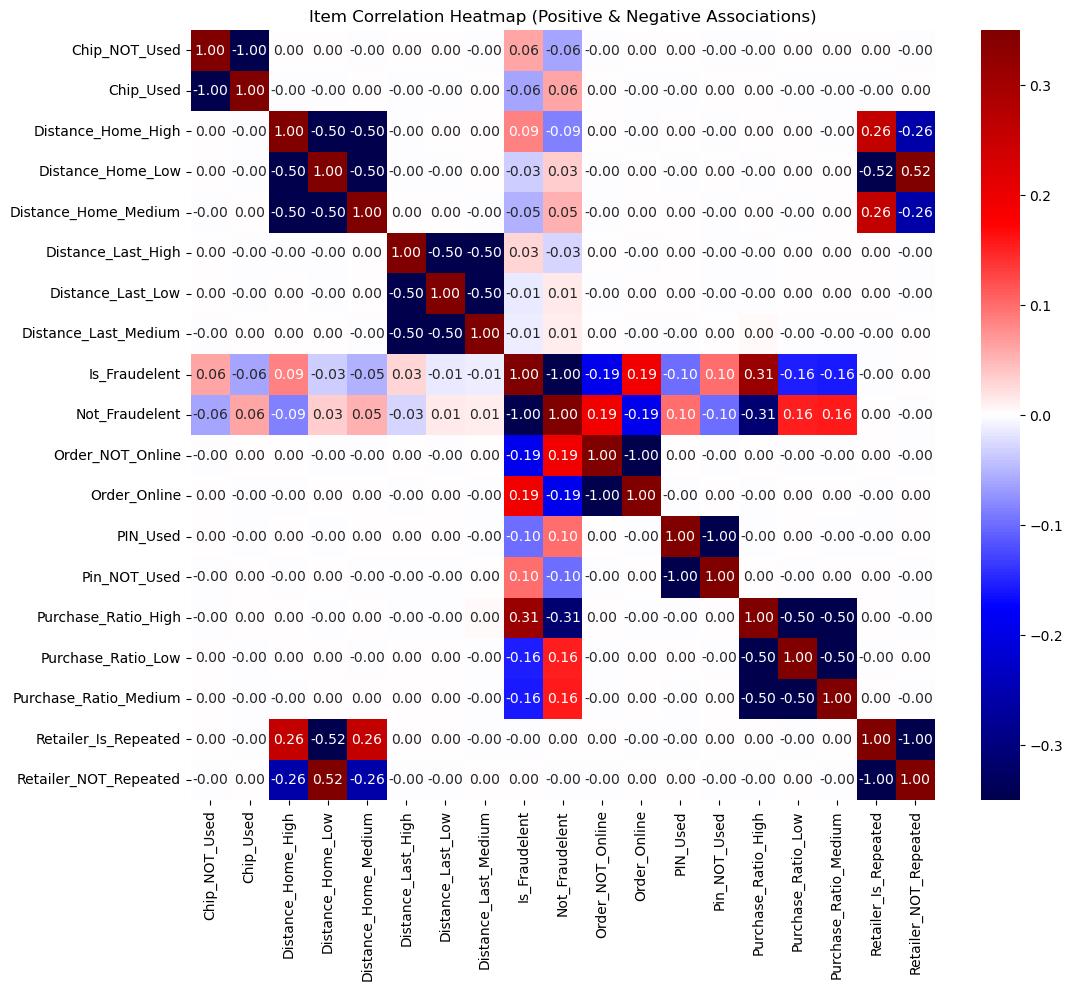

In [ ]:
# Calculate the support of each item
item_support = transaction_df.mean()

# Keep only items appearing in at least 1% of transactions
min_support = 0.01
items_to_keep = item_support[item_support >= min_support].index

# Filter to only keep the items in the boudnary we set
transaction_filtered = transaction_df[items_to_keep]
# Calculating pairwise operation
corr_filtered = transaction_filtered.corr()


# Plot the heatmap
plt.figure(figsize=(12,10))

sns.heatmap(
    corr_filtered,
    annot=True,
    fmt=".2f",
    cmap="seismic",
    center=0,
    vmin=-0.35,
    vmax=0.35
)

# Giving title
plt.title("Item Correlation Heatmap (Positive & Negative Associations)")
plt.show()

<div style="background-color: lightblue; padding: 10px; color: black; font-size: 16px;">
The correlation matrix confirms the previous findinds we had. Looking into the row with the 'Is_Fraudulent' variable, we can see that there is a strong positive relationship between Purcahse_Ratio_High and Is_Fraudulent (r = 0.31) as we saw earlier. Transactions that are much larger than a customer's normal spending habit are more likely to be fraudulent. Order online also has a positive relationship with Is_Fraudulent (r = 0.19) showing that fraud is more commom in online relationsips. Transactions without PIN verification shows a slight positive relationship with fraud (r= 0.1). Lastly, transactions that are farther away from home are slightly associated with fraud (r = 0.09).
    Conversley, in terms of negative relationships, transactions with purchase ratio of low and medium, offline transactions, and transaction the need PIN verification demonstrate negative relationships with fraudulent activity.
</div>

# Recommendations for Actionable Steps

Based on the findings there are several recommendations that financial institutions can implement to better detect fraudulent transactions:
1. Increase monitoring for unusually large online purchases: The strong association rules found consistently included high purchase ratio and online purchases as characteristics for fraudulent transactions. This shows that online purchases that are extremely larger than a customer's usual spending habit need additional review to make sure they are legitimate. The institution can implement additional authentication for these transactions to help reduce fraudulent activity while slowing the process for real customers.
2. Do not assume transactions at familiar retailers are always low in risk: Many of the strong rules detected showed Retailer_Is_Repeated which indicates that fraudulent transactions can also happen at ratailers that the customer has previous purchases at. Therefore, fraud detection systems should avoid relying only on this characteristic and assume that if the retailer is familiar, then the transaction is legitimate. They should inspect this characteristic alongside other transaction characteristics and evaluate.
3. Strengthen authentication transactions that are high in risk: Several of the strong rules included Pin_NOT_Used which shows that PIN verification was not used during purchase, even if the transaction was online and the purchase ratio was high (Pin_NOT_Used, Order_Online, Purchase_Ratio_High -> Retailer_Is_Repeated, Is_Fraudelent). Financial institutions should consider applying additional authentication steps, such as multi-step verification, when multiple high-risk characteristics happen together (such as online purchase along with large amounts)